In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import xml.etree.ElementTree as ET
import pandas as pd

import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent.parent
# add to sys path, to find module for dependencies
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import scripts.src.inputs.config as cfg

In [32]:
PALETTE_RUNNING = sns.color_palette("Blues", as_cmap=True)
PALETTE_FAILURES = sns.color_palette("coolwarm", as_cmap=True)

In [37]:
path_summary_base_am_no_tls  = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_base_no_TLS/Summary_base_AM.xml")

path_summary_day_no_tls  = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/Summary_marouter_scaled0.7.xml")
path_day_tls = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_with_TLS/Summary_marouter_DAY.xml")


path_summary_am_ma_notls = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/Summary_marouter_AM.xml")
path_summary_pm_ma_no_tls = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/Summary_marouter_PM.xml")

path_summary_am_ma_tls = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_with_TLS/Summary_marouter2_AM.xml")
path_summary_pm_ma_tls = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_with_TLS/Summary_marouter_PM.xml")

path_summary_day_ma_no_tls = Path("/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/Summary_marouter_scaled0.5.xml")

# labels = ["am_tls", "am_no_tls", "pm_tls", "pm_no_tls", "day_tls", "day_no_tls"]
# path_list = [path_summary_am_tls, path_summary_am_no_tls, path_summary_pm_tls, path_summary_pm_no_tls, path_summary_day_tls, path_summary_day_no_tls]

# path_list = [path_summary_am_tls, path_summary_am_no_tls, path_summary_pm_tls, path_summary_pm_no_tls, path_summary_day_tls, path_summary_day_no_tls]

In [38]:
def parse_sumo_summary(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    data = []
    for step in root.findall('step'):
        data.append(step.attrib)
    
    df = pd.DataFrame(data).apply(pd.to_numeric, errors='ignore')
    return df

# dfs_seconds = {label: parse_sumo_summary(path) for label, path in zip(labels, path_list)}

# df_summary_base_am_no_tls = parse_sumo_summary(path_summary_base_am_no_tls)
# df_summary_am_tls = parse_sumo_summary(path_summary_am_tls)
# df_summary_pm_no_tls = parse_sumo_summary(path_summary_pm_no_tls)
# df_summary_pm_tls = parse_sumo_summary(path_summary_pm_tls)
# df_summary_day_no_tls = parse_sumo_summary(path_summary_day_no_tls)
# df_summary_day_tls = parse_sumo_summary(path_summary_day_tls)

df_base_day_no_TLS = parse_sumo_summary(path_summary_day_no_tls)
# df_base_day_with_TLS = parse_sumo_summary(path_day_tls)
df_ma_am_notls = parse_sumo_summary(path_summary_am_ma_notls)
df_ma_pm_notls = parse_sumo_summary(path_summary_pm_ma_no_tls)
df_ma_day_notls = parse_sumo_summary(path_summary_day_ma_no_tls)

# df_ma_am_tls = parse_sumo_summary(path_summary_am_ma_tls)
# df_ma_pm_tls = parse_sumo_summary(path_summary_pm_ma_tls)

/tmp/ipykernel_2874512/1030315817.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = pd.DataFrame(data).apply(pd.to_numeric, errors='ignore')


In [39]:
def datetime_format(df_summary):
    df_summary['time'] = pd.to_datetime(df_summary['time'], unit='s')
    df_summary['meanWaitingTime_dt'] = pd.to_datetime(df_summary['meanWaitingTime'], unit='s')
    df_summary['meanTravelTime_dt']  = pd.to_datetime(df_summary['meanTravelTime'],  unit='s')

    return df_summary

#df_summary_base_am_no_tls = datetime_format(df_summary_base_am_no_tls)
# df_summary_am_tls = datetime_format(df_summary_am_tls)
# df_summary_pm_no_tls = datetime_format(df_summary_pm_no_tls)
# df_summary_pm_tls = datetime_format(df_summary_pm_tls)
# df_summary_day_no_tls = datetime_format(df_summary_day_no_tls)
# df_summary_day_tls = datetime_format(df_summary_day_tls)
# df_sum_load2 = datetime_format(df_sum_load2)
df_sum_day_no_tls = datetime_format(df_base_day_no_TLS)
# df_sum_day_with_tls = datetime_format(df_base_day_with_TLS)
df_ma_am_notls = datetime_format(df_ma_am_notls)
df_ma_pm_notls = datetime_format(df_ma_pm_notls)
df_ma_day_notls = datetime_format(df_ma_day_notls)

# df_ma_am_tls = datetime_format(df_ma_am_tls)
# df_ma_pm_tls = datetime_format(df_ma_pm_tls)

In [ ]:
# fig, axs = plt.subplots(
#     2, 1, figsize=(15, 15), constrained_layout=True
# )
# sns.lineplot(df_summary, x="time", y="meanSpeed", ax=axs[0])
# axs[0].set_title('Mean speed')
# sns.lineplot(df_summary, x="time", y="meanTravelTime", ax=axs[1])
# axs[1].set_title('Mean Travel Time')

RUNNING VS HALTING: 
    misura di performance della rete - quanti veicoli si stanno muovendo e quanti stanno attendendo?

INSERTED VS ARRIVED:
    fatto cento dei veicoli inseriti in simulazione, quanti sono giunti a destinazione?




In [23]:
def ax_style(
    ax,
    title: str,
    ylabel: str,
    load_start: int,
    load_end: int,
    xlim: int=None,
    load_start_2: int = None,
    load_end_2: int = None,
    xlabel: str = "Time (h)",
):

    # X-axis time conversion
    xlim_dt = pd.to_datetime(xlim, unit="s")
    load_start_dt = pd.to_datetime(load_start, unit="s")
    load_end_dt = pd.to_datetime(load_end, unit="s")

    ax.axvspan(load_start_dt, load_end_dt, color="blue", alpha=0.1, label="Load")
    if load_start_2 is not None and load_end_2 is not None:
        load_start_dt_2 = pd.to_datetime(load_start_2, unit="s")
        load_end_dt_2 = pd.to_datetime(load_end_2, unit="s")
        ax.axvspan(
            load_start_dt_2,
            load_end_dt_2,
            color="orange",
            linestyle="--",
            alpha=0.1,
            label="Load",
        )
    elif load_start_2 is not None or load_end_2 is not None:
        raise ValueError("Both load_start_2 and load_end_2 must be provided together.")
    
    ax.set_title(title, fontweight="semibold", pad=10)
    ax.set_ylabel(ylabel)
    ax.set_xlim(right=xlim_dt)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.legend(loc="best", frameon=False, fontsize="small")

In [24]:
def plot_summary(
    df_summary: pd.DataFrame,
    title: str,
    load_start: int,
    load_end: int,
    load_start_2: int = None,
    load_end_2: int = None,
    xlim: int = None,
):

    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 2, figsize=(16, 12), constrained_layout=True)
    fig.suptitle(f"SUMO Summary - {title}", fontsize=14, fontweight="bold")

    # RUNNING VS HALTING
    sns.lineplot(
        data=df_summary,
        x="time",
        y="running",
        ax=axs[0, 0],
        label="Running",
        color="blue",
    )
    sns.lineplot(
        data=df_summary,
        x="time",
        y="halting",
        ax=axs[0, 0],
        label="Halting",
        color="red",
    )
    ax_style(
        ax=axs[0, 0],
        #xlim=xlim,
        title="Net congestion",
        ylabel="Number of vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    # INSERTED VS ARRIVED
    sns.lineplot(
        data=df_summary,
        x="time",
        y="inserted",
        ax=axs[0, 1],
        label="Inserted",
        color="green",
    )
    sns.lineplot(
        data=df_summary,
        x="time",
        y="arrived",
        ax=axs[0, 1],
        label="Arrived",
        color="darkred",
    )
    ax_style(
        ax=axs[0, 1],
        #xlim=xlim,
        title="Inserted vs Arrived",
        ylabel="Cumulative total",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    # SPEED CHECK
    ax_speed_rel = axs[1, 0].twinx()  # NO ASSE UGUALE, MEAN RELATIVE è SCALATA
    sns.lineplot(
        data=df_summary,
        x="time",
        y="meanSpeed",
        ax=axs[1, 0],
        color="lightblue",
        label="AVG speed (m/s)",
    )
    sns.lineplot(
        data=df_summary,
        x="time",
        y="meanSpeedRelative",
        ax=ax_speed_rel,
        color="grey",
        label="AVG Rel Speed (%)",
        alpha=0.5,
    )
    ax_style(
        ax=axs[1, 0],
        #xlim=xlim,
        title="Average speed and average relative speed",
        ylabel="Speed (m/s)",
        load_start=load_start,
        load_end=load_end,
    )

    ax_speed_rel.set_ylabel("Ratio with respect to the limit")
    # set combined legend
    lines, labels = axs[1, 0].get_legend_handles_labels()
    lines2, labels2 = ax_speed_rel.get_legend_handles_labels()
    ax_speed_rel.legend(lines + lines2, labels + labels2, loc="best")
    axs[1, 0].get_legend().remove()


    # AVERAGE TIME
    sns.lineplot(
        data=df_summary,
        x="time",
        y="meanWaitingTime_dt",
        ax=axs[1, 1],
        color="orange",
        label="AVG waiting time",
    )
    sns.lineplot(
        data=df_summary,
        x="time",
        y="meanTravelTime_dt",
        ax=axs[1, 1],
        color="green",
        label="AVG travel time",
    )
    ax_style(
        ax=axs[1, 1],
        #xlim=xlim,
        title="Running and waiting times",
        ylabel="Time (h)",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )
    axs[1, 1].yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    # INFRASTRUCTURE PERFORMANCE
    sns.lineplot(
        data=df_summary,
        x="time",
        y="inserted",
        label="Inserted",
        color="#2E7D32",
        linewidth=2,
        ax=axs[2, 0],
    )  # Number of vehicles inserted so far (including reported time step)
    sns.lineplot(
        data=df_summary,
        x="time",
        y="loaded",
        label="Loaded",
        color="#FFA000",
        ax=axs[2, 0],
    )  # Number of vehicles that were loaded from input files up to this time step. This can included vehicle with depart times in the future.

    sns.lineplot(
        data=df_summary,
        x="time",
        y="waiting",
        label="Waiting",
        color="#F70A0A",
        linewidth=2,
        ax=axs[2, 0],
    )  # Number of vehicles inserted so far (including reported time step)

    ax_style(
        ax=axs[2, 0],
        #xlim=xlim,
        title="Infrastructure performance",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    # INCONVENIENCES
    sns.lineplot(
        data=df_summary,
        x="time",
        y="collisions",
        label="Collisions",
        color="#CA4514",
        linewidth=2,
        ax=axs[2, 1],
    )
    sns.lineplot(
        data=df_summary,
        x="time",
        y="discarded",
        label="Discarded",
        color="#DF0707",
        ax=axs[2, 1],
    )

    sns.lineplot(
        data=df_summary,
        x="time",
        y="teleports",
        label="Teleports",
        color="#0951CE",
        linewidth=2,
        ax=axs[2, 1],
    )

    ax_style(
        ax=axs[2, 1],
        #xlim=xlim,
        title="Simulation failures",
        ylabel="Number of events",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    # Shared x-axes
    for ax in [axs[0, 1], axs[2, 0]]:
        ax.sharey(axs[2, 0])

    plt.show()

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# ─────────────────────────── PALETTE ────────────────────────────
COLORS = {
    "running":         "#1565C0",   # blu scuro
    "halting":         "#C62828",   # rosso scuro
    "inserted":        "#2E7D32",   # verde scuro
    "arrived":         "#6A1515",   # bordeaux
    "loaded":          "#E65100",   # arancione scuro
    "waiting_veh":     "#B71C1C",   # rosso
    "mean_speed":      "#0277BD",   # blu medio
    "mean_speed_rel":  "#78909C",   # grigio blu
    "mean_wait":       "#F57F17",   # giallo scuro
    "mean_travel":     "#388E3C",   # verde medio
    "collisions":      "#BF360C",
    "discarded":       "#D32F2F",
    "teleports":       "#1565C0",
    "ins_hour":        "#2E7D32",
    "wait_hour":       "#F57F17",
    "run_hour":        "#1565C0",
}

LOAD_COLOR_1 = (0.3, 0.5, 1.0, 0.10)   # blu – picco mattutino
LOAD_COLOR_2 = (1.0, 0.70, 0.1, 0.12)  # oro – picco serale


# ─────────────────────── HELPER FUNCTIONS ───────────────────────

def _style(ax, title: str, ylabel: str):
    ax.set_facecolor("#FAFAFA")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel("time", fontsize=10)
    ax.tick_params(labelsize=10)
    ax.grid(True, color="#DDDDDD", linewidth=0.6, linestyle="--")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right") # setp = Set one or more properties on an Artist, or list allowed values.


def _shade_load_window(ax, df, load_start, load_end, load_start_2=None, load_end_2=None):
    t = df["time"]
    if load_start is not None and load_end is not None:
        ax.axvspan(t.iloc[load_start], t.iloc[min(load_end, len(t)-1)],
                color=LOAD_COLOR_1, zorder=0, label="Load 1")
    if load_start_2 is not None and load_end_2 is not None:
        ax.axvspan(t.iloc[load_start_2], t.iloc[min(load_end_2, len(t)-1)],
                color=LOAD_COLOR_2, zorder=0, label="Load 2")


def _legend(ax, loc="upper left"):
    ax.legend(loc=loc, fontsize=9, framealpha=0.6,
            facecolor="white", edgecolor="#BBBBBB")


def _compute_hourly(df: pd.DataFrame) -> pd.DataFrame:
    tmp = df.copy()
    tmp["hour"] = tmp["time"].dt.floor("h")
    ins = (
        tmp.groupby("hour")["inserted"]
        .agg(lambda s: s.iloc[-1] - s.iloc[0])
        .reset_index()
        .rename(columns={"inserted": "inserted_per_hour"})
    )
    wr = (
        tmp.groupby("hour")[["waiting", "running"]]
        .mean()
        .reset_index()
        .rename(columns={"waiting": "waiting_per_hour",
                        "running": "running_per_hour"})
    )
    return ins.merge(wr, on="hour")


# ─────────────────────────── MAIN PLOT ──────────────────────────

def plot_all_metrics(
    df_summary: pd.DataFrame,
    title: str,
    load_start: int,
    load_end: int,
    load_start_2: int = None,
    load_end_2: int = None,
    xlim: int = None,
):
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor":   "#FAFAFA",
        "text.color":       "#222222",
        "font.family":      "sans-serif",
    })

    df = df_summary.iloc[:xlim] if xlim else df_summary.copy()

    fig = plt.figure(figsize=(18, 17), constrained_layout=True)
    fig.patch.set_facecolor("white")
    fig.suptitle(f"SUMO Summary – {title}", fontsize=16, fontweight="bold")

    # Grid 4x2 (last = unique plot 1x2)
    gs = gridspec.GridSpec(
        nrows=4, ncols=2,
        figure=fig,
        height_ratios=[1, 1, 1, 1.0],
    )

    # Define subplot - grid pos correspondence
    axs = [[fig.add_subplot(gs[r, c]) for c in range(2)] for r in range(3)] # 2 cols, 3 rows
    ax_hourly = fig.add_subplot(gs[3, :]) 

    args = dict(df=df, load_start=load_start, load_end=load_end,
            load_start_2=load_start_2, load_end_2=load_end_2)

    # ── 1-0  Net Congestion (Ex Riga 1) ──────────────────────────────────────
    ax = axs[0][0]
    ax.plot(df["time"], df["running"], color=COLORS["running"], lw=1.5, label="Running")
    ax.plot(df["time"], df["halting"], color=COLORS["halting"], lw=1.5, label="Halting")
    _shade_load_window(ax, **args)
    _style(ax, "Net Congestion", "Number of vehicles")
    _legend(ax)

    # ── 1-1  Inserted vs Arrived (Ex Riga 1) ─────────────────────────────────
    ax = axs[0][1]
    ax.plot(df["time"], df["inserted"], color=COLORS["inserted"], lw=1.5, label="Inserted")
    ax.plot(df["time"], df["arrived"],  color=COLORS["arrived"],  lw=1.5, label="Arrived")
    _shade_load_window(ax, **args)
    _style(ax, "Inserted vs Arrived", "Cumulative total")
    _legend(ax)

    # ── 2-0  Speed (doppio asse) (Ex Riga 2) ──────────────────────────────────
    ax  = axs[1][0]
    ax2 = ax.twinx()
    ax.plot(df["time"], df["meanSpeed"],
            color=COLORS["mean_speed"], lw=1.4, label="AVG speed (m/s)")
    ax2.plot(df["time"], df["meanSpeedRelative"],
            color=COLORS["mean_speed_rel"], lw=1.1, alpha=0.6, label="AVG Rel Speed")
    _shade_load_window(ax, **args)
    _style(ax, "Average Speed & Relative Speed", "Speed (m/s)")
    ax2.set_ylabel("Ratio w.r.t. speed limit", fontsize=8)
    ax2.tick_params(labelsize=8)
    for spine in ax2.spines.values():
        spine.set_edgecolor("#CCCCCC")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(handles=h1+h2, labels=l1+l2, loc="lower right", fontsize=7,
            framealpha=0.6, facecolor="white", edgecolor="#BBBBBB")

    # ── 2-1  Waiting & Travel Time (Ex Riga 2) ───────────────────────────────
    ax = axs[1][1]
    ax.plot(df["time"], df["meanWaitingTime_dt"],
            color=COLORS["mean_wait"],  lw=1.5, label="AVG waiting time")
    ax.plot(df["time"], df["meanTravelTime_dt"],
            color=COLORS["mean_travel"], lw=1.5, label="AVG travel time")
    _shade_load_window(ax, **args)
    _style(ax, "Running & Waiting Times", "Time")
    ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    _legend(ax)

    # ── 3-0  Infrastructure Performance (Ex Riga 3) ─────────────────────────
    ax = axs[2][0]
    ax.plot(df["time"], df["inserted"], color=COLORS["inserted"], lw=1.8, label="Inserted")
    ax.plot(df["time"], df["loaded"],  color=COLORS["loaded"], lw=1.2, label="Loaded")
    ax.plot(df["time"], df["waiting"], color=COLORS["waiting_veh"], lw=1.8, label="Waiting")
    _shade_load_window(ax, **args)
    ax.set_yscale('log')
    _style(ax, "Infrastructure Performance", "Number of Vehicles")
    _legend(ax)

    # ── 3-1  Simulation Failures (Ex Riga 3) ─────────────────────────────────
    ax = axs[2][1]
    ax.plot(df["time"], df["collisions"], color=COLORS["collisions"], lw=1.8, label="Collisions")
    ax.plot(df["time"], df["discarded"], color=COLORS["discarded"],  lw=1.2, label="Discarded")
    ax.plot(df["time"], df["teleports"], color=COLORS["teleports"],  lw=1.8, label="Teleports")
    _shade_load_window(ax, **args)
    _style(ax, "Simulation Failures", "Number of events")
    _legend(ax)

    # ── 4  Metriche orarie – spostate in BASSO (Inversione completata) ──────────
    hourly = _compute_hourly(df)
    ax = ax_hourly # large 1x2 - all the row
    ax.plot(hourly["hour"], hourly["inserted_per_hour"],
            color=COLORS["ins_hour"],  lw=2.0, marker="o", ms=4, label="Inserted / hour")
    ax.plot(hourly["hour"], hourly["waiting_per_hour"],
            color=COLORS["wait_hour"], lw=2.0, marker="s", ms=4, label="Avg Waiting / hour")
    ax.plot(hourly["hour"], hourly["running_per_hour"],
            color=COLORS["run_hour"],  lw=2.0, marker="^", ms=4, label="Avg Running / hour")
    _shade_load_window(ax, df, load_start, load_end, load_start_2, load_end_2)
    _style(ax, "Hourly metrics: Inserted / Avg Waiting / Avg Running", "Vehicles")
    _legend(ax)

    plt.savefig("sumo_summary.png", dpi=350, bbox_inches="tight", facecolor="white")
    plt.show()

In [26]:
def plot_compare_summaries(
    df_summary: pd.DataFrame,
    df_summary_2: pd.DataFrame = None,
    title: str = "Comparison",
    label_1: str = "Sim 1",
    label_2: str = "Sim 2",
    load_start: int = None,
    load_end: int = None,
    load_start_2: int = None,
    load_end_2: int = None,
    xlim: int = None,
):
    sns.set_theme(style="whitegrid")
    fig, axs = plt.subplots(3, 2, figsize=(16, 14), constrained_layout=True)
    fig.suptitle(f"SUMO Comparison - {title}", fontsize=16, fontweight="bold")

    def plot_two_df(column, ax, color1, color2, ylabel, title_sub):
        sns.lineplot(
            data=df_summary,
            x="time",
            y=column,
            ax=ax,
            label=f"{label_1} {column}",
            color=color1,
            linewidth=2,
        )

        if df_summary_2 is not None:
            sns.lineplot(
                data=df_summary_2,
                x="time",
                y=column,
                ax=ax,
                label=f"{label_2} {column}",
                color=color2,
                linestyle="--",
                alpha=0.8,
            )

        ax_style(
            ax=ax,
            xlim=xlim,
            title=title_sub,
            ylabel=ylabel,
            load_start=load_start,
            load_end=load_end,
            load_start_2=load_start_2,
            load_end_2=load_end_2,
            )

    # 1. NET CONGESTION (Running vs Halting)
    plot_two_df("running", axs[0, 0], "blue", "blue", "Vehicles", "Running vs Halting")
    plot_two_df("halting", axs[0, 0], "red", "red", "Vehicles", "Running vs Halting")

    # 2. INSERTED VS ARRIVED
    plot_two_df("inserted", axs[0, 1], "green", "green", "Vehicles", "Inserted vs Arrived")
    plot_two_df("arrived", axs[0, 1], "darkred", "darkred", "Vehicles", "Inserted vsArrived")

    # 3. SPEED
    sns.lineplot(
        data=df_summary,
        x="time",
        y="meanSpeed",
        ax=axs[1, 0],
        label=label_1,
        color="green",
    )
    if df_summary_2 is not None:
        sns.lineplot(
            data=df_summary_2,
            x="time",
            y="meanSpeed",
            ax=axs[1, 0],
            label=label_2,
            color="lightgreen",
            linestyle="--",
        )
    ax_style(
        ax=axs[1, 0],
        xlim=xlim,
        title="Mean Speed (m/s)",
        ylabel="m/s",
        load_start=load_start,
        load_end=load_end,
    )

    # 4. WAITING TIME
    plot_two_df(
        "meanWaitingTime",
        axs[1, 1],
        "darkorange",
        "gold",
        "Time (s)",
        "Average Waiting Time",
    )

    # 5. INFRASTRUCTURE (Waiting)
    plot_two_df(
        "waiting",
        axs[2, 0],
        "red",
        "red",
        "Vehicles",
        "Vehicles Waiting to Start",
    )
    plot_two_df(
        "loaded",
        axs[2, 0],
        "orange",
        "orange",
        "Vehicles",
        "Vehicles Waiting to Start",
    )
    
    plot_two_df(
        "inserted",
        axs[2, 0],
        "green",
        "green",
        "Vehicles",
        "Vehicles Waiting to Start",
    )

    # 6. TELEPORTS (Inconveniences)
    plot_two_df("teleports", axs[2, 1], "brown", "tan", "Events", "Teleports")

    plt.show()

In [27]:
def plot_net_performace(
    df_tls: pd.DataFrame,
    df_no_tls: pd.DataFrame,
    xlim: int,
    title: str,
    load_start: int,
    load_end: int,
    load_start_2: int = None,
    load_end_2: int = None,
):

    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(20, 14), constrained_layout=True)
    fig.suptitle(f"Net congestion comparison - {title}", fontsize=18, fontweight="bold")

    sns.lineplot(
        data=df_tls, x="time", y="running", color="blue", label="ON", ax=axs[0]
    )
    sns.lineplot(
        data=df_no_tls, x="time", y="running", label="OFF", color="blue", ax=axs[0], linestyle='-', linewidth=2
    )

    sns.lineplot(
        data=df_tls, x="time", y="halting", color="red", label="ON", ax=axs[1]
    )

    sns.lineplot(
        data=df_no_tls, x="time", y="halting", label="OFF", color="red", ax=axs[1], linestyle='-', linewidth=2
    )

    sns.lineplot(
        data=df_tls, x="time", y="teleports", color="darkviolet", label="ON", ax=axs[2]
    )

    sns.lineplot(
        data=df_no_tls, x="time", y="teleports", label="OFF", color="darkviolet", ax=axs[2], linestyle='-', linewidth=2
    )

    ax_style(
        ax=axs[0],
        xlim=xlim,
        title="Running",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    ax_style(
        ax=axs[1],
        xlim=xlim,
        title="Halting",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    ax_style(
        ax=axs[2],
        xlim=xlim,
        title="Teleports",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    handles, labels = plt.gca().get_legend_handles_labels()
    dedup_label = dict(zip(labels, handles))
    fig.legend(
        dedup_label.keys(),
        dedup_label.values(),
        loc="upper right",
        bbox_to_anchor=(1, 1),
        fancybox=True,
    )

    plt.show()

In [28]:
def plot_time_metrics(
    df_tls: pd.DataFrame,
    df_no_tls: pd.DataFrame,
    xlim: int,
    title: str,
    load_start: int,
    load_end: int,
    load_start_2: int = None,
    load_end_2: int = None,
):

    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True, sharey=True)
    fig.suptitle(f"Time metrics comparison - {title}", fontsize=18, fontweight="bold")

    def single_time_plot(df: pd.DataFrame, ax, title_subplot: str):
        sns.lineplot(
            data=df,
            x="time",
            y="meanWaitingTime_dt",
            ax=ax,
            color="orange",
            label="AVG waiting time",
        )
        sns.lineplot(
            data=df,
            x="time",
            y="meanTravelTime_dt",
            ax=ax,
            color="green",
            label="AVG travel time",
        )
        ax_style(
            ax=ax,
            xlim=xlim,
            title=title_subplot,
            ylabel="Time (h)",
            load_start=load_start,
            load_end=load_end,
            load_start_2=load_start_2,
            load_end_2=load_end_2,
        )

    single_time_plot(df_tls, axs[0], "With 2 TLS on")
    single_time_plot(df_no_tls, axs[1], "All TLS off")

    for i in range(len(axs)):
        axs[i].yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

In [40]:
from typing import Dict, List
from typing import TypedDict


class AlgoInfo(TypedDict):
    title: str
    df: pd.DataFrame


def compare_algos(
    algo_dataframes: List[AlgoInfo],
    title: str,
    load_start: int,
    load_end: int,
    load_start_2: int = None,
    load_end_2: int = None,
    xlim: int = None,
):

    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(20, 14), constrained_layout=True)
    algos_string = " vs. ".join([x["title"] for x in algo_dataframes])
    fig.suptitle(
        f"Net congestion comparison - {algos_string} ({title})",
        fontsize=18,
        fontweight="bold",
    )

    for a in algo_dataframes:
        sns.lineplot(
            data=a["df"],
            x="time",
            y="running",
            label=a["title"],
            palette=PALETTE_RUNNING,
            ax=axs[0],
        )

        sns.lineplot(
            data=a["df"],
            x="time",
            y="halting",
            palette=PALETTE_RUNNING,
            label=a["title"],
            ax=axs[1],
        )

        sns.lineplot(
            data=a["df"],
            x="time",
            y="teleports",
            palette=PALETTE_FAILURES,
            label=["title"],
            ax=axs[2],
        )

    ax_style(
        ax=axs[0],
        xlim=xlim,
        title="Running",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    ax_style(
        ax=axs[1],
        xlim=xlim,
        title="Halting",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    ax_style(
        ax=axs[2],
        xlim=xlim,
        title="Teleports",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    handles, labels = plt.gca().get_legend_handles_labels()
    dedup_label = dict(zip(labels, handles))
    fig.legend(
        dedup_label.keys(),
        dedup_label.values(),
        loc="upper right",
        bbox_to_anchor=(1, 1),
        fancybox=True,
    )

    plt.show()


In [14]:
def compare_routings(
    df_no_tls: pd.DataFrame,
    df_duaiterate_logit: pd.DataFrame,
    df_duaiterate_gawron: pd.DataFrame,
    xlim: int,
    title: str,
    load_start: int,
    load_end: int,
    load_start_2: int = None,
    load_end_2: int = None,
):

    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(20, 14), constrained_layout=True)
    fig.suptitle(f"Net congestion comparison - Duarouter vs Duaiterate ({title})", fontsize=18, fontweight="bold")

    sns.lineplot(
        data=df_duaiterate_logit, x="time", y="running", label="dua_logit", palette=PALETTE_RUNNING, ax=axs[0]
    )
    sns.lineplot(
        data=df_no_tls, x="time", y="running", label="duarouter", palette=PALETTE_RUNNING, ax=axs[0]
    )

    sns.lineplot(
        data=df_duaiterate_gawron, x="time", y="running", label="dua_gawron", palette=PALETTE_RUNNING, ax=axs[0]
    )

    sns.lineplot(data=df_duaiterate_logit, x="time", y="halting", color="red", label="dua_logit", ax=axs[1])

    sns.lineplot(data=df_duaiterate_gawron, x="time", y="halting", color="darkred", label="dua_gawron", ax=axs[1])

    sns.lineplot(
        data=df_no_tls, x="time", y="halting", label="duarouter", color="orange", ax=axs[1]
    )

    sns.lineplot(
        data=df_duaiterate_logit, x="time", y="teleports", palette=PALETTE_FAILURES, label="dua_logit", ax=axs[2]
    )

    sns.lineplot(
        data=df_no_tls, x="time", y="teleports", label="duarouter", palette=PALETTE_FAILURES, ax=axs[2]
    )

    sns.lineplot(
        data=df_duaiterate_gawron, x="time", y="teleports", label="dua_gawron", palette=PALETTE_FAILURES, ax=axs[2]
    )

    ax_style(
        ax=axs[0],
        xlim=xlim,
        title="Running",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    ax_style(
        ax=axs[1],
        xlim=xlim,
        title="Halting",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    ax_style(
        ax=axs[2],
        xlim=xlim,
        title="Teleports",
        ylabel="Number of Vehicles",
        load_start=load_start,
        load_end=load_end,
        load_start_2=load_start_2,
        load_end_2=load_end_2,
    )

    handles, labels = plt.gca().get_legend_handles_labels()
    dedup_label = dict(zip(labels, handles))
    fig.legend(
        dedup_label.keys(),
        dedup_label.values(),
        loc="upper right",
        bbox_to_anchor=(1, 1),
        fancybox=True,
    )

    plt.show()

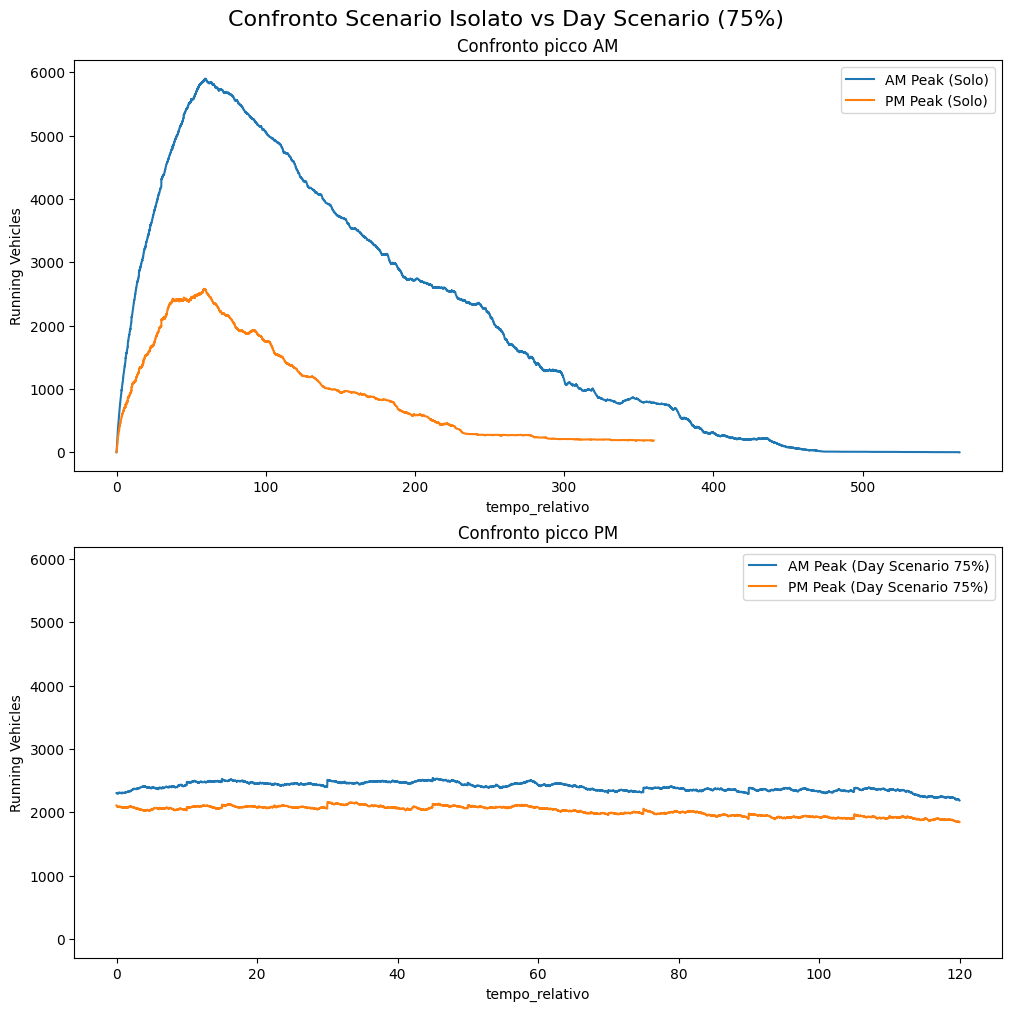

In [15]:
#subset am
filtro_am = (df_base_day_no_TLS['time'] >= '1970-01-01 08:00:00') & (df_base_day_no_TLS['time'] <= '1970-01-01 10:00:00')
df_am_day = df_base_day_no_TLS[filtro_am].copy()


df_ma_am_notls['tempo_relativo'] = (pd.to_datetime(df_ma_am_notls['time']) - pd.to_datetime(df_ma_am_notls['time']).min()).dt.total_seconds() / 60
df_am_day['tempo_relativo'] = (pd.to_datetime(df_am_day['time']) - pd.to_datetime(df_am_day['time']).min()).dt.total_seconds() / 60

#subset pm
filtro_pm = (df_base_day_no_TLS['time'] >= '1970-01-01 18:00:00') & (df_base_day_no_TLS['time'] <= '1970-01-01 20:00:00')
df_pm_day = df_base_day_no_TLS[filtro_pm].copy()

df_ma_pm_notls['tempo_relativo'] = (pd.to_datetime(df_ma_pm_notls['time']) - pd.to_datetime(df_ma_pm_notls['time']).min()).dt.total_seconds() / 60
df_pm_day['tempo_relativo'] = (pd.to_datetime(df_pm_day['time']) - pd.to_datetime(df_pm_day['time']).min()).dt.total_seconds() / 60


fig, ax = plt.subplots(2, 1, figsize=(10, 10), constrained_layout=True, sharey=True)
fig.suptitle("Confronto Scenario Isolato vs Day Scenario (75%)", fontsize=16)

# comapre am
sns.lineplot(data=df_ma_am_notls, x='tempo_relativo', y='running', ax=ax[0], label="AM Peak (Solo)")
sns.lineplot(data=df_am_day, x='tempo_relativo', y='running', ax=ax[1], label="AM Peak (Day Scenario 75%)")
ax[0].set_title("Confronto picco AM")
ax[0].set_ylabel("Running Vehicles")
ax[0].legend() 
# compare pm
sns.lineplot(data=df_ma_pm_notls, x='tempo_relativo', y='running', ax=ax[0], label="PM Peak (Solo)")
sns.lineplot(data=df_pm_day, x='tempo_relativo', y='running', ax=ax[1], label="PM Peak (Day Scenario 75%)")
ax[1].set_title("Confronto picco PM")
ax[1].set_ylabel("Running Vehicles")
ax[1].legend()

for a in ax:
    a.tick_params(axis='x', rotation=0)

plt.show()

In [16]:
# plot_summary(df_sum_load2, title="PM LOAD 2H",load_start=18*3600, load_end=20*3600)

In [ ]:
inserted = max(df_sum_day_no_tls['inserted'])
inserted

161313

KeyboardInterrupt: 

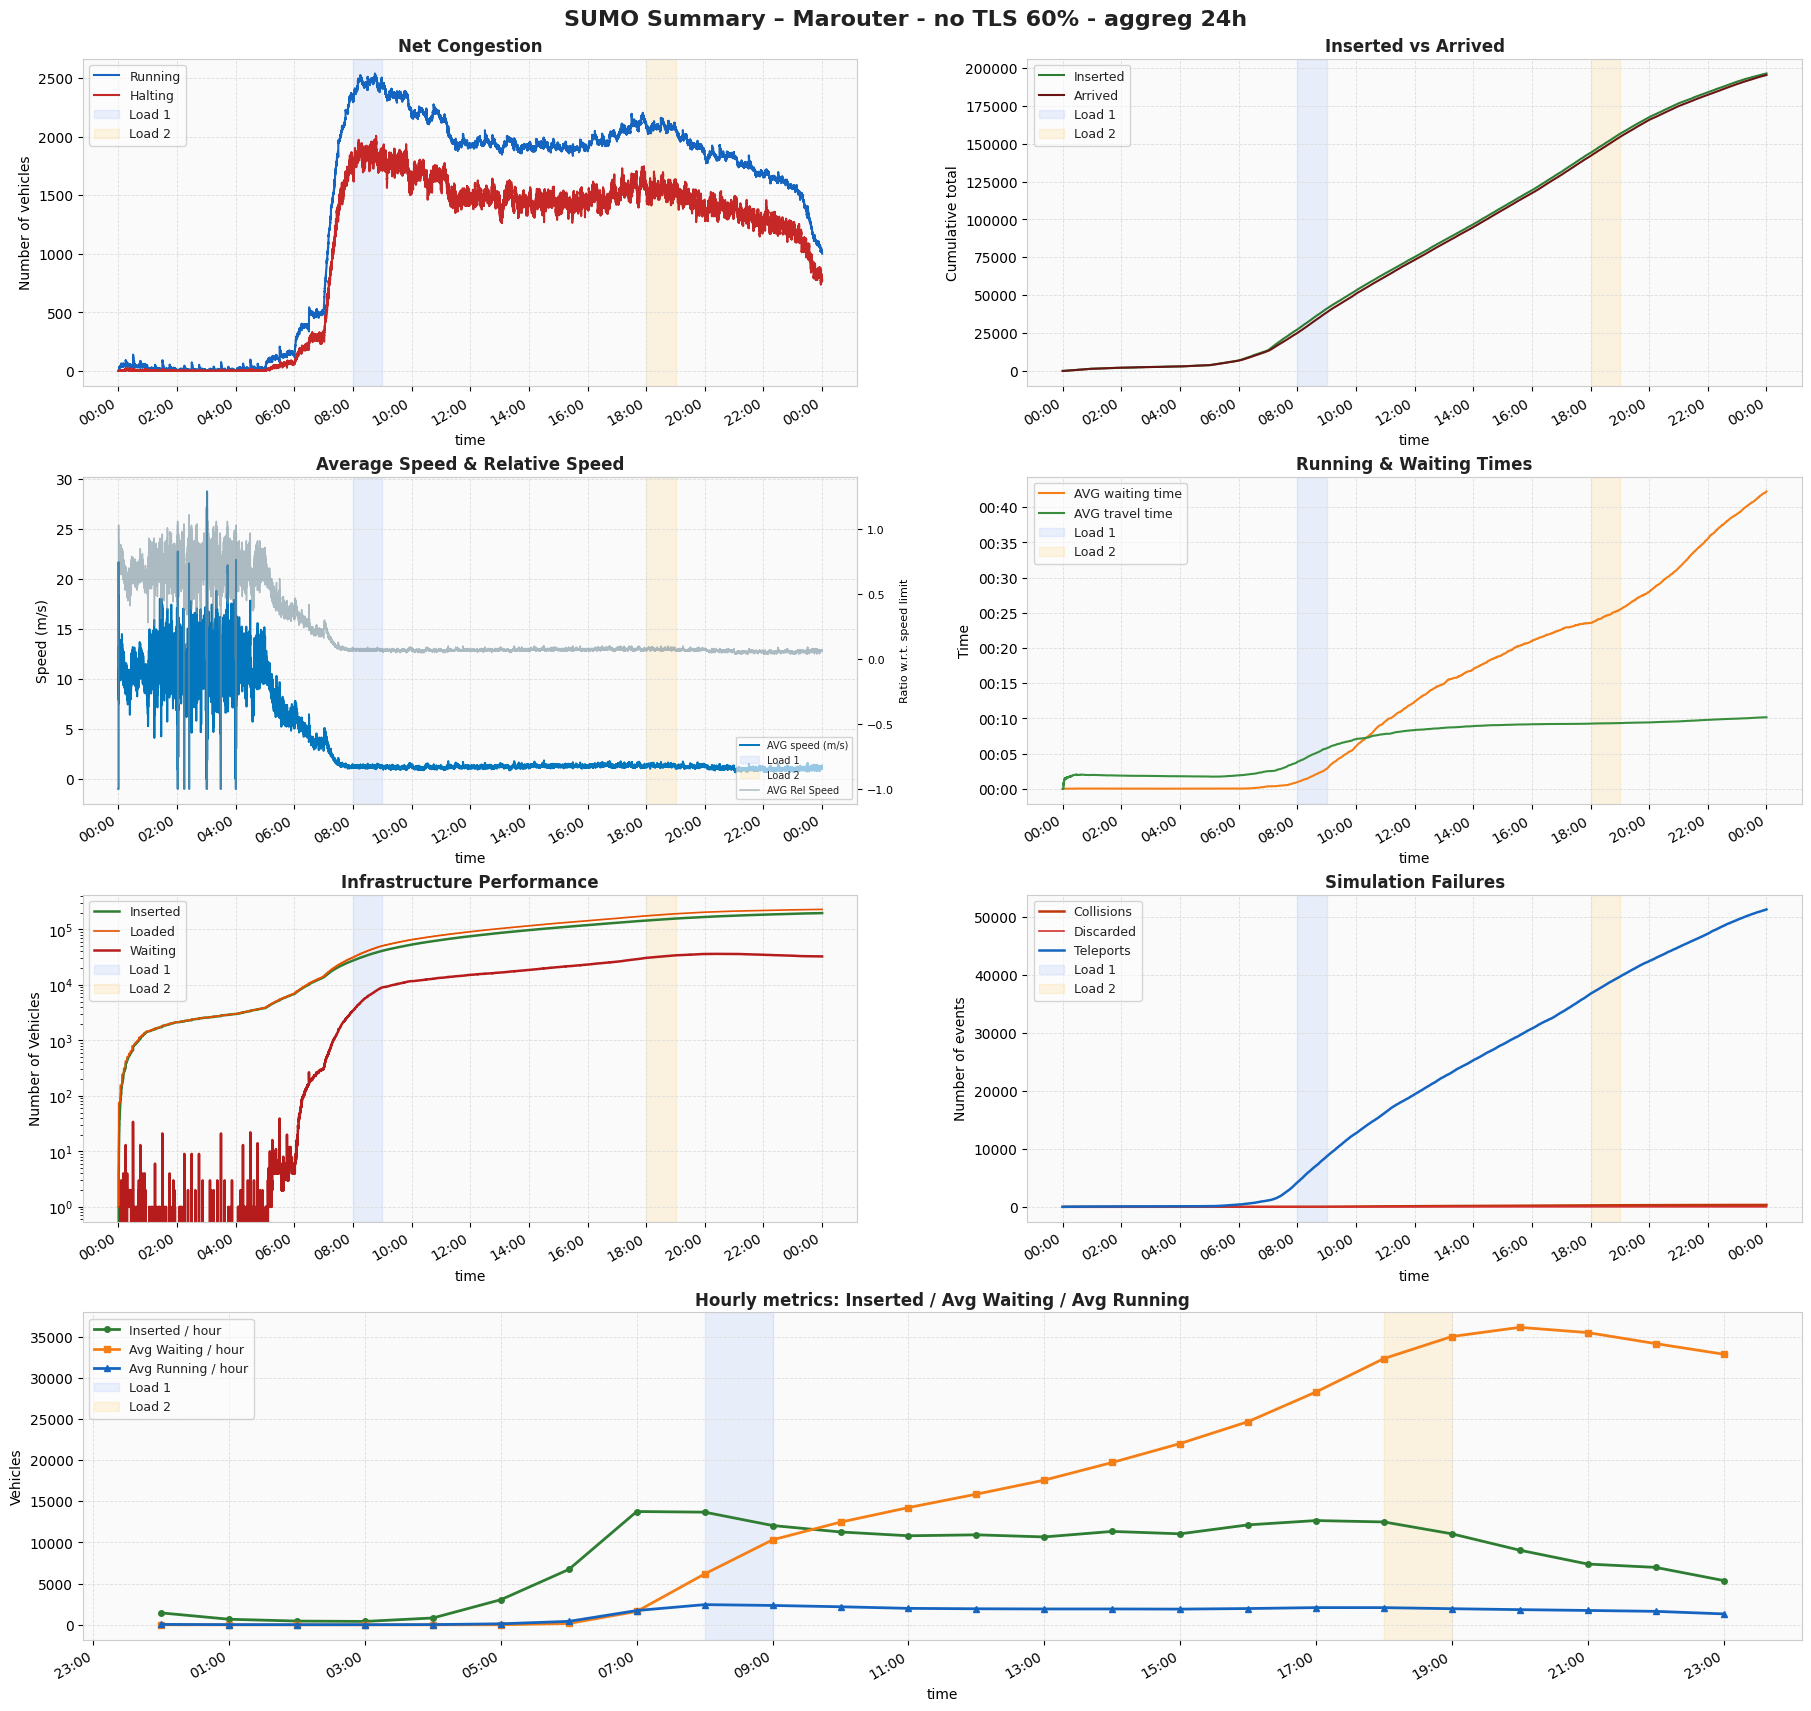

In [16]:
plot_all_metrics(df_sum_day_no_tls, title="Marouter - no TLS 60% - aggreg 24h", load_start = 8*3600, load_end=9*3600, load_start_2=18*3600, load_end_2=19*3600)

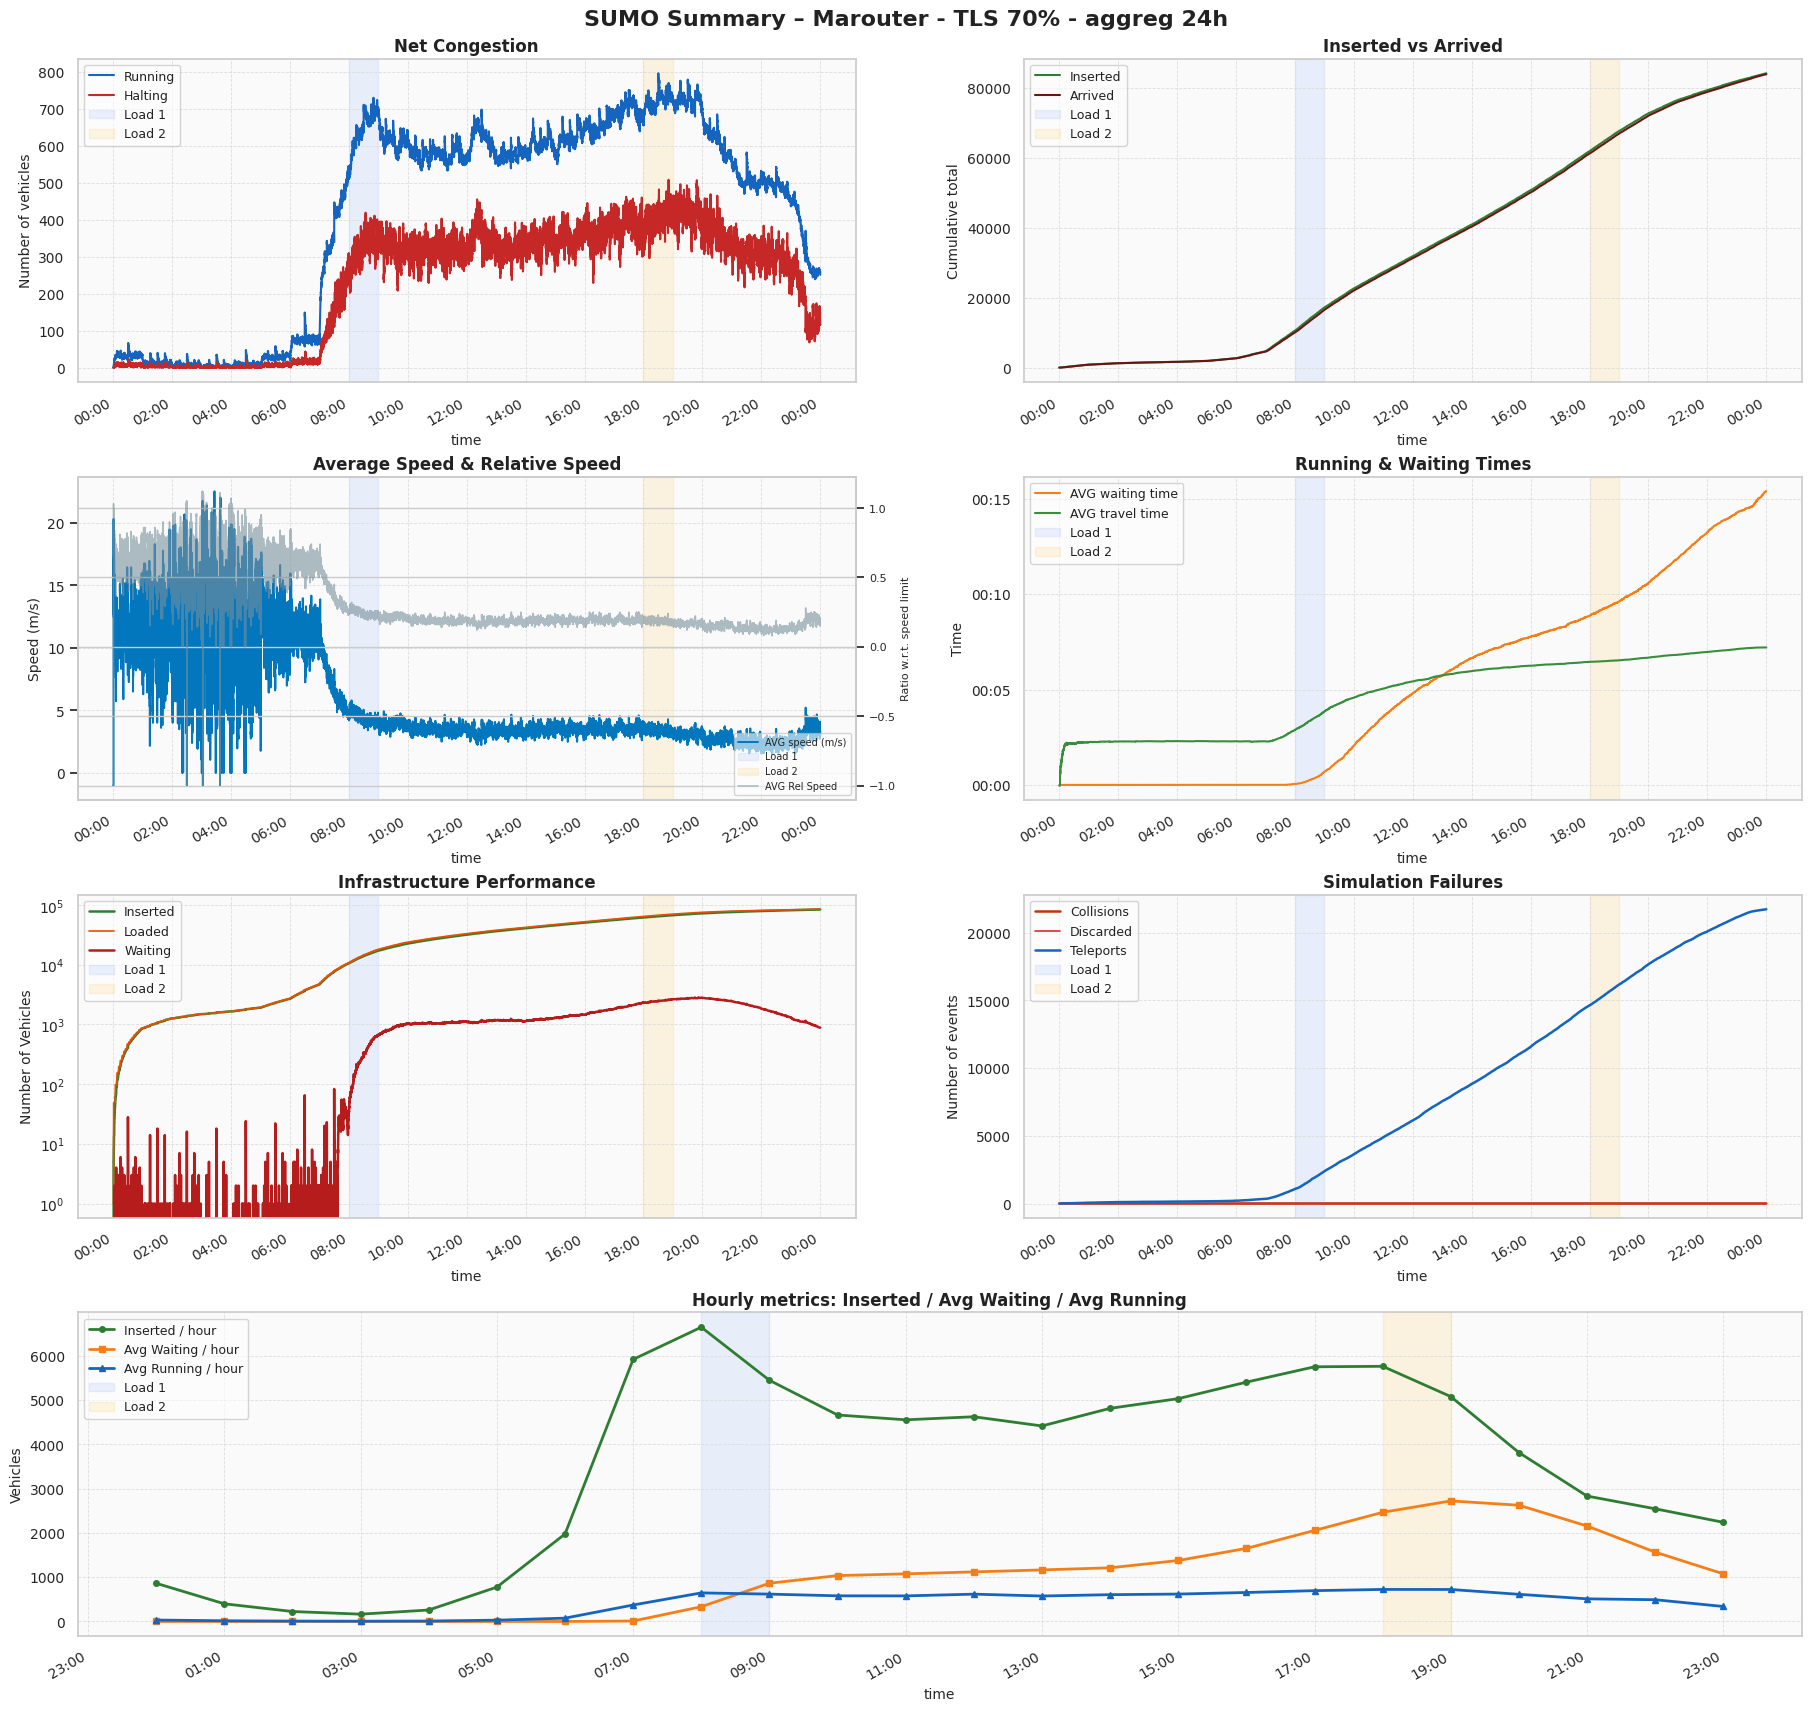

In [ ]:
plot_all_metrics(
    df_sum_day_with_tls,
    title="Marouter - TLS 70% - aggreg 24h",
    load_start=8 * 3600,
    load_end=9 * 3600,
    load_start_2=18 * 3600,
    load_end_2=19 * 3600,
)

## MORNING PEAK

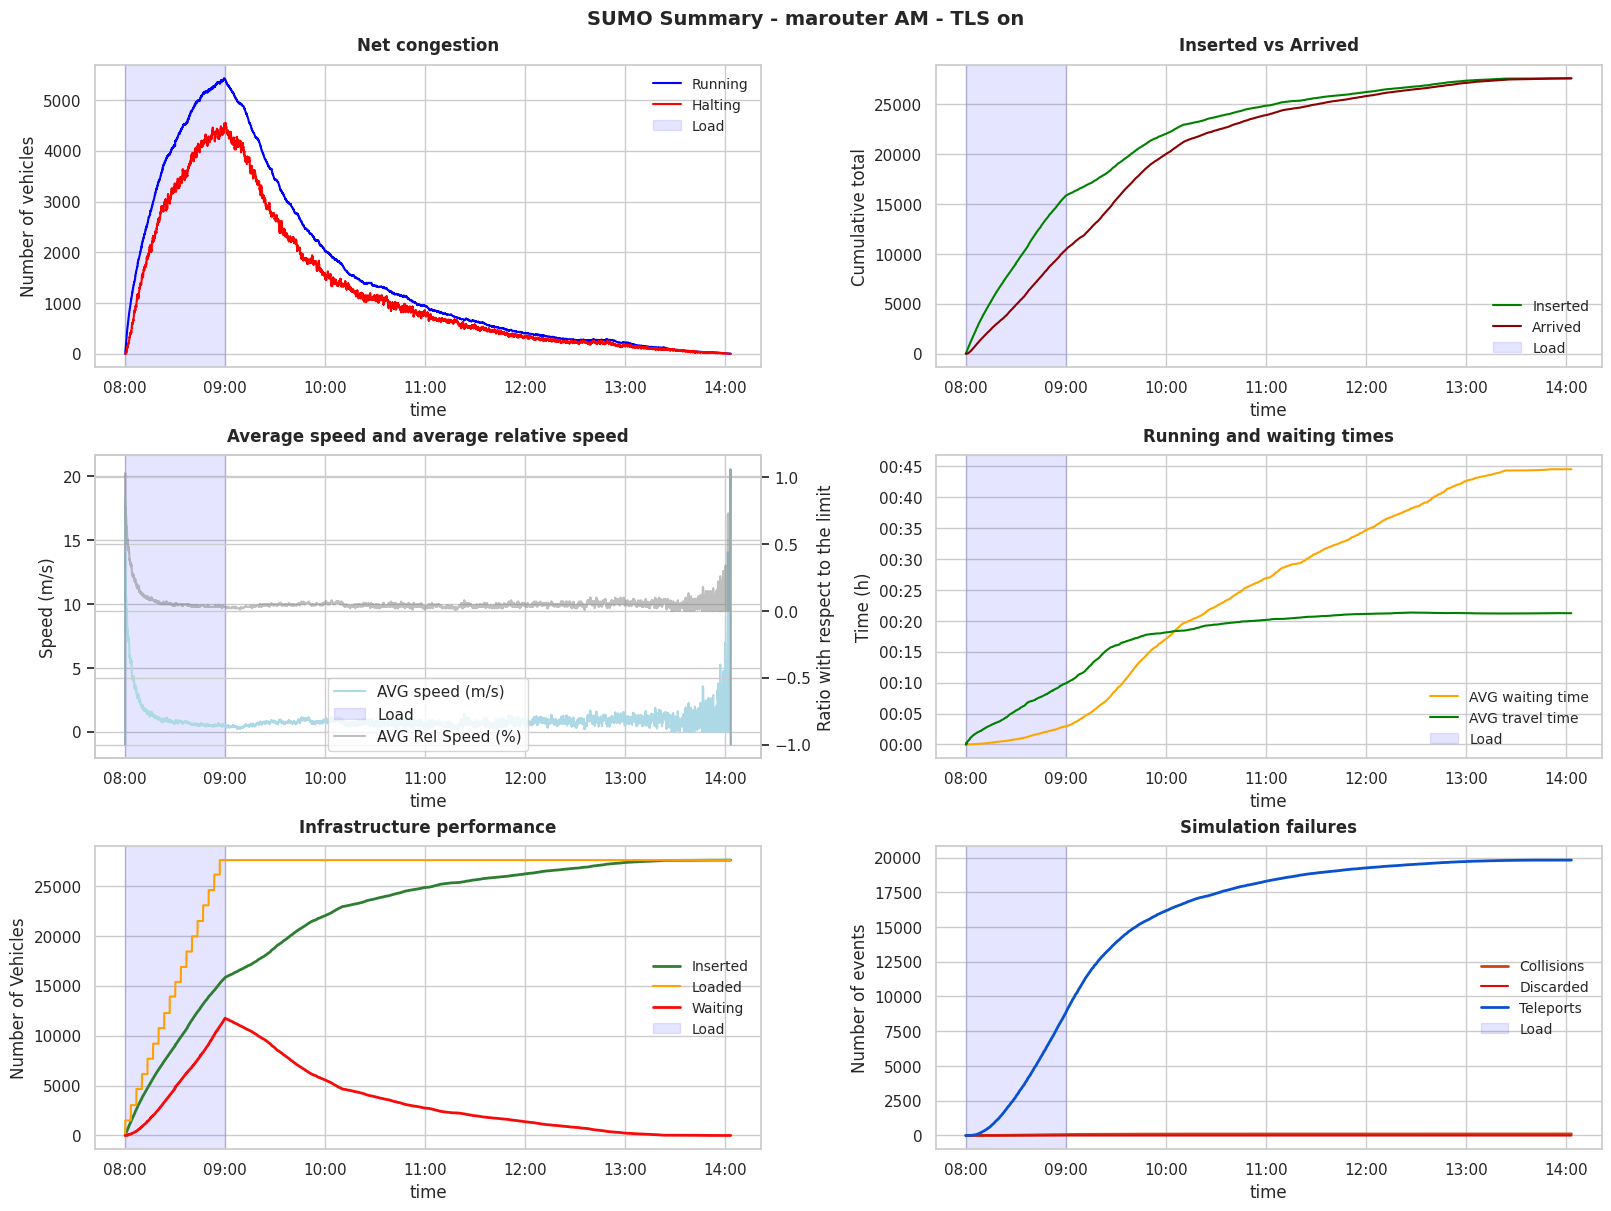

In [18]:
plot_summary(
    df_ma_am_tls,
    title="marouter AM - TLS on",
    xlim=10*3600,
    load_start=8*3600,
    load_end=9*3600,
)

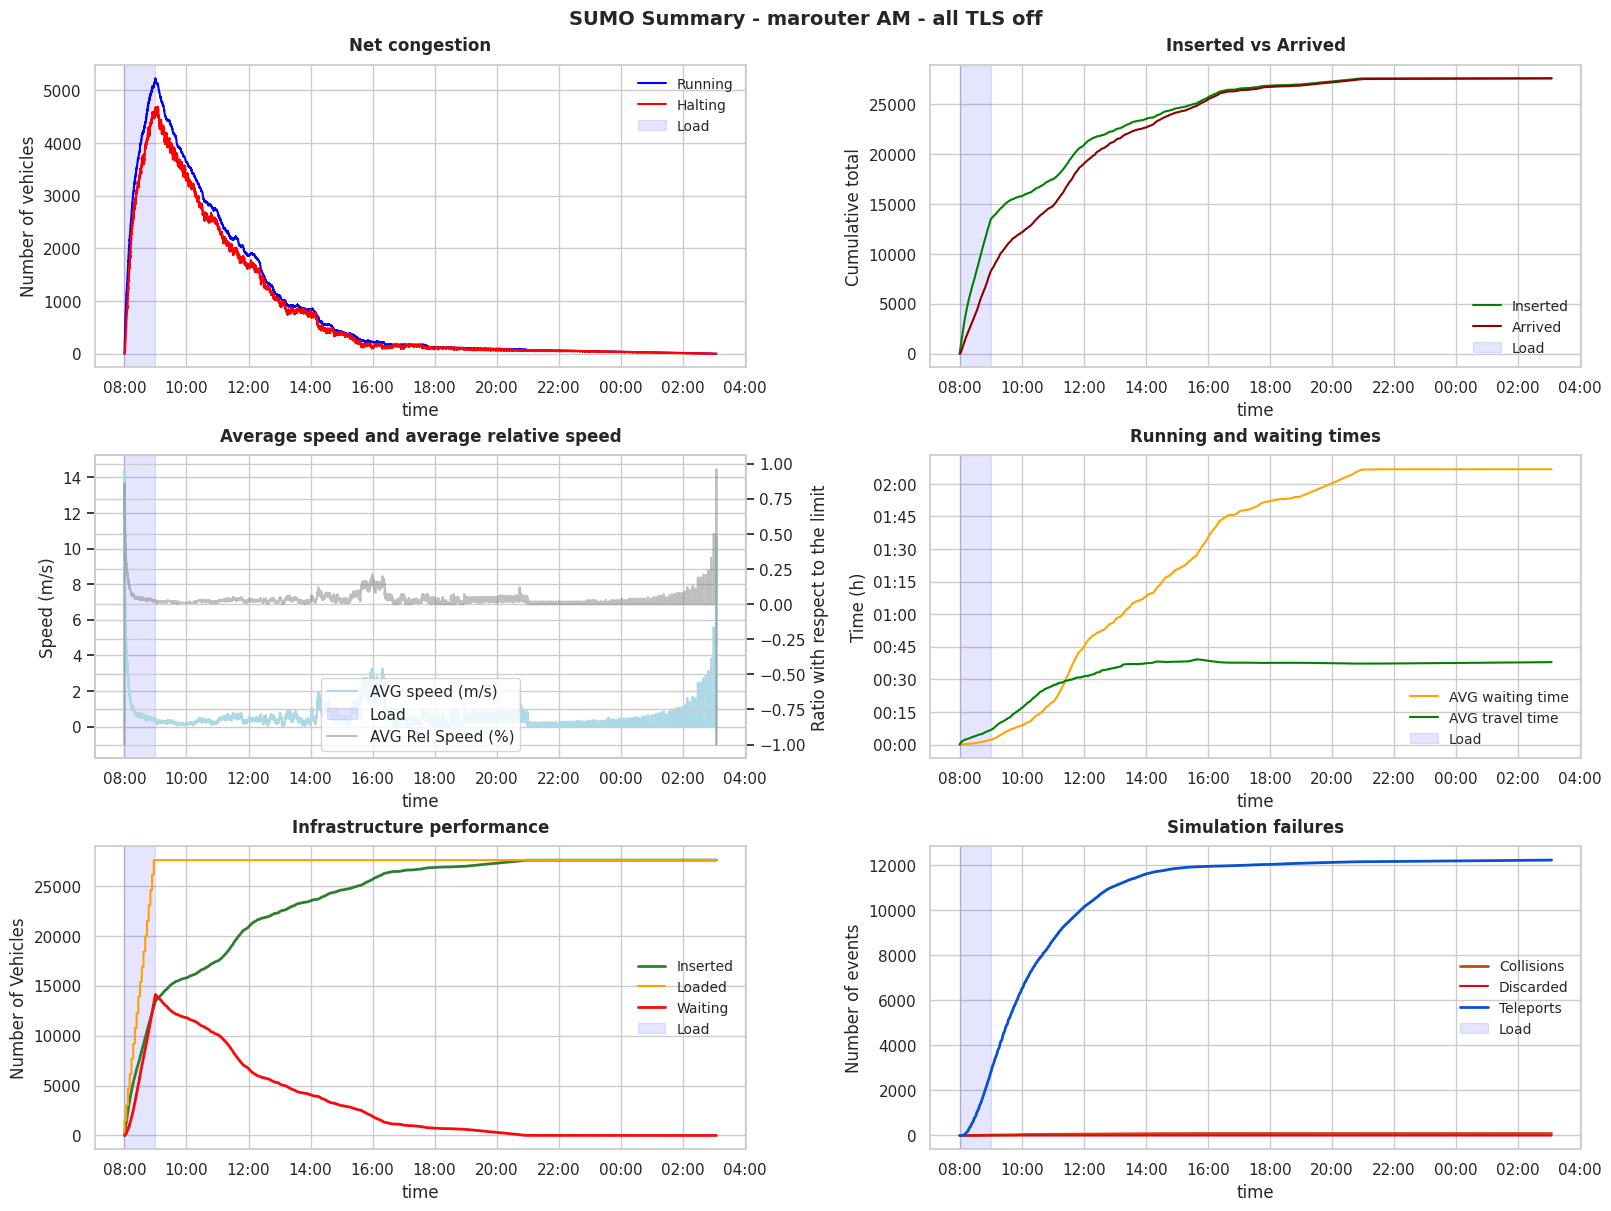

In [41]:
plot_summary(
    df_ma_am_notls,
    title="marouter AM - all TLS off",
    xlim=10*3600,
    load_start=8*3600,
    load_end=9*3600,
)

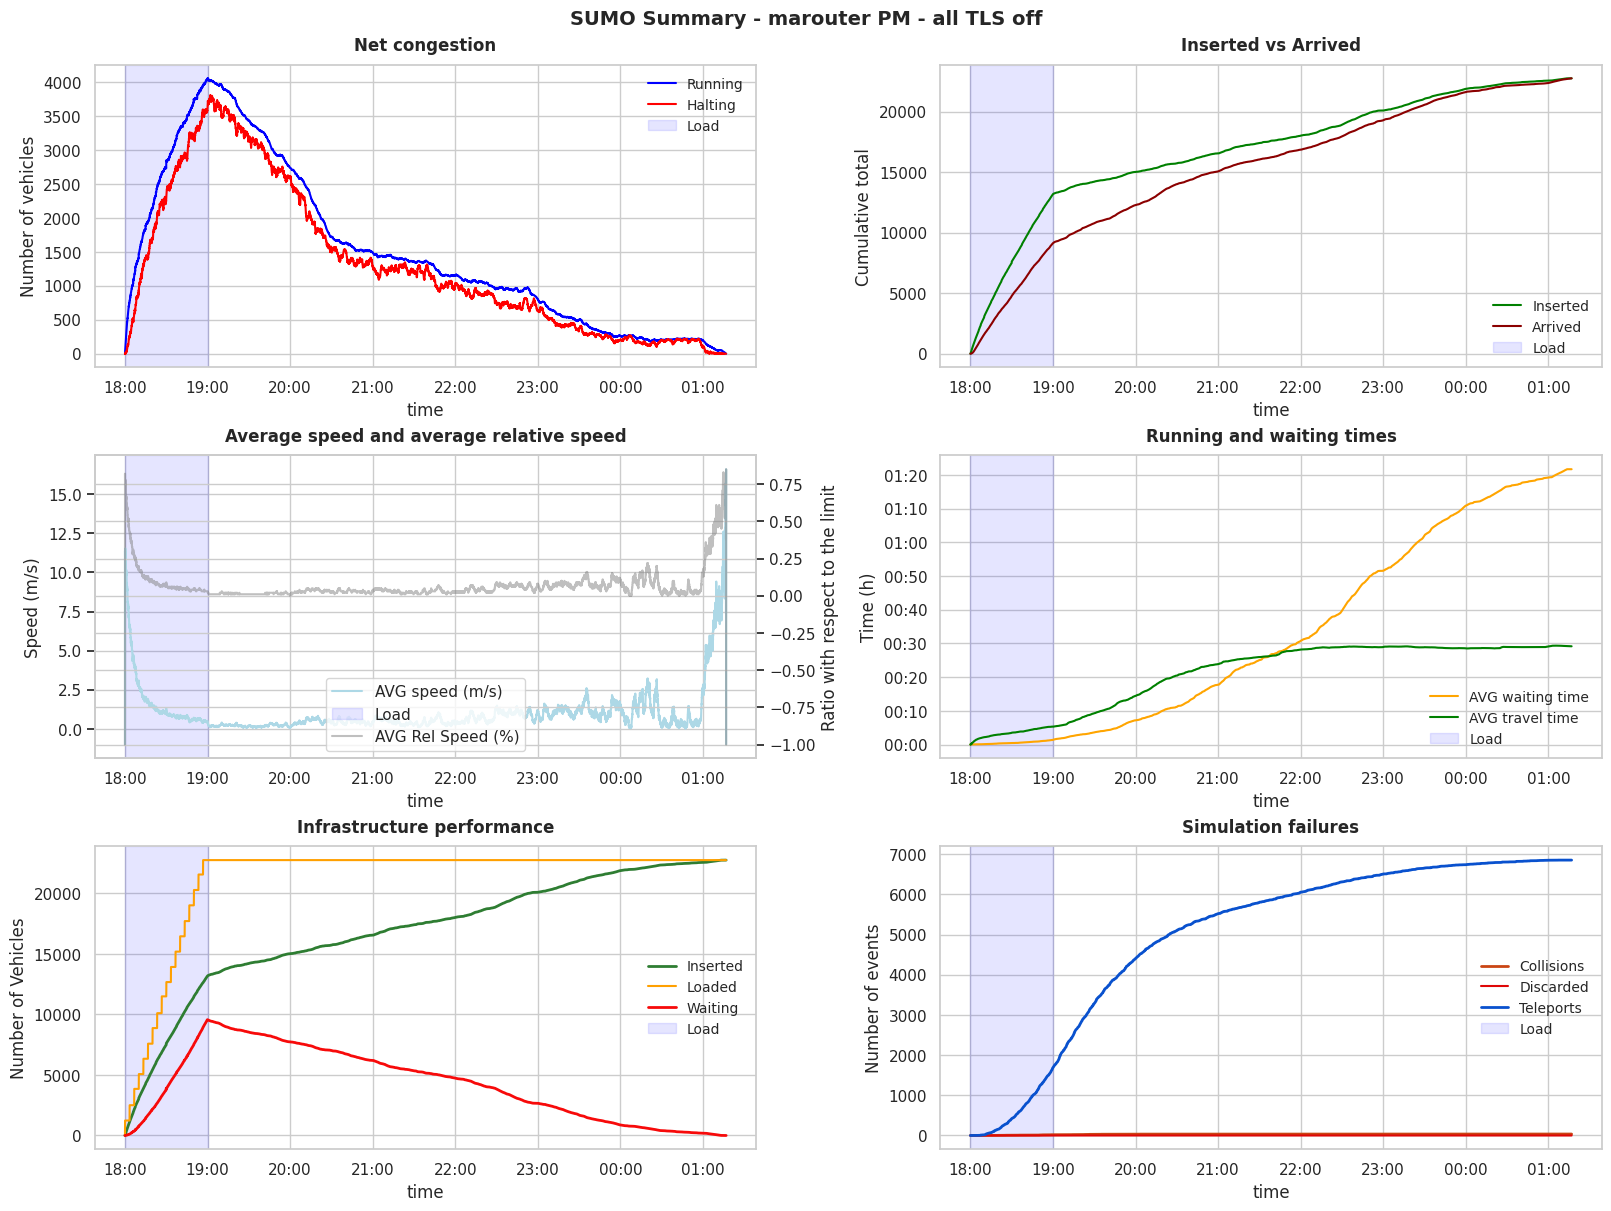

In [30]:
plot_summary(
    df_ma_pm_notls,
    title="marouter PM - all TLS off",
    xlim=20*3600,
    load_start=18*3600,
    load_end=19*3600,
)

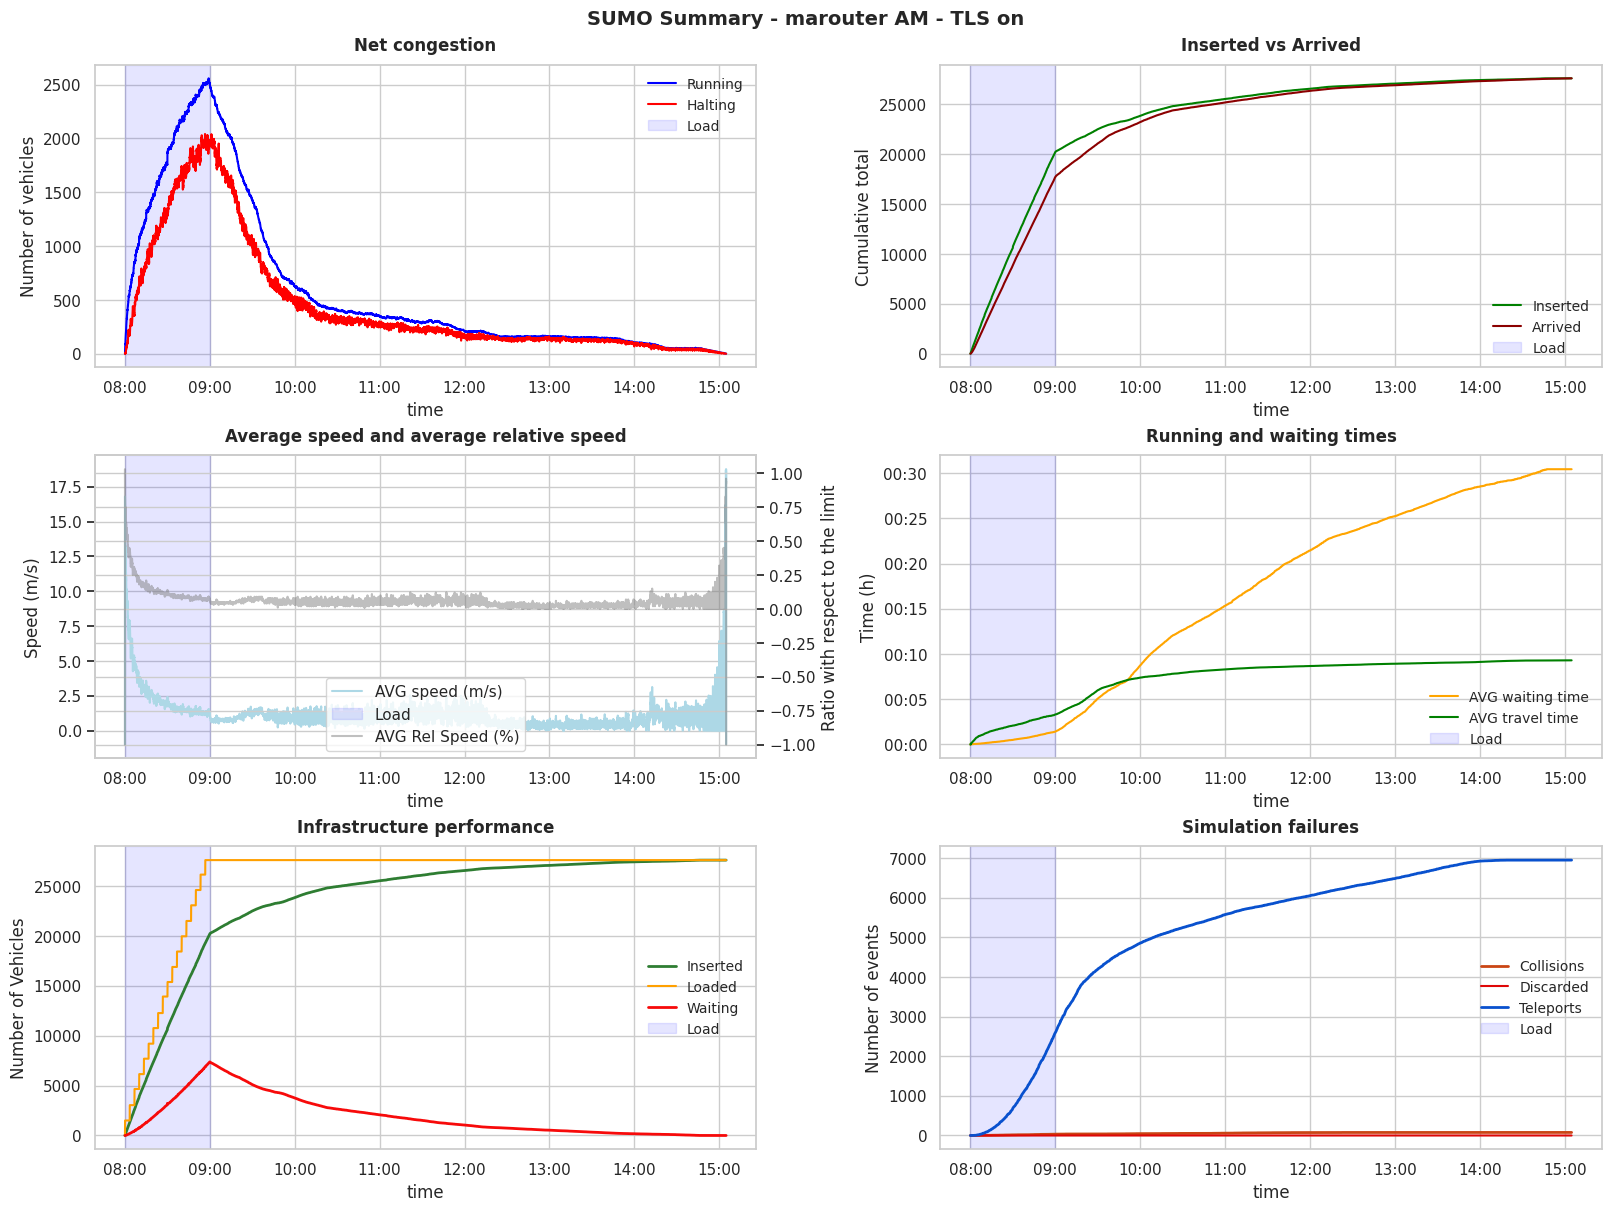

In [18]:
plot_summary(
    df_ma_am_tls,
    title="marouter AM - TLS on",
    xlim=10*3600,
    load_start=8*3600,
    load_end=9*3600,
)

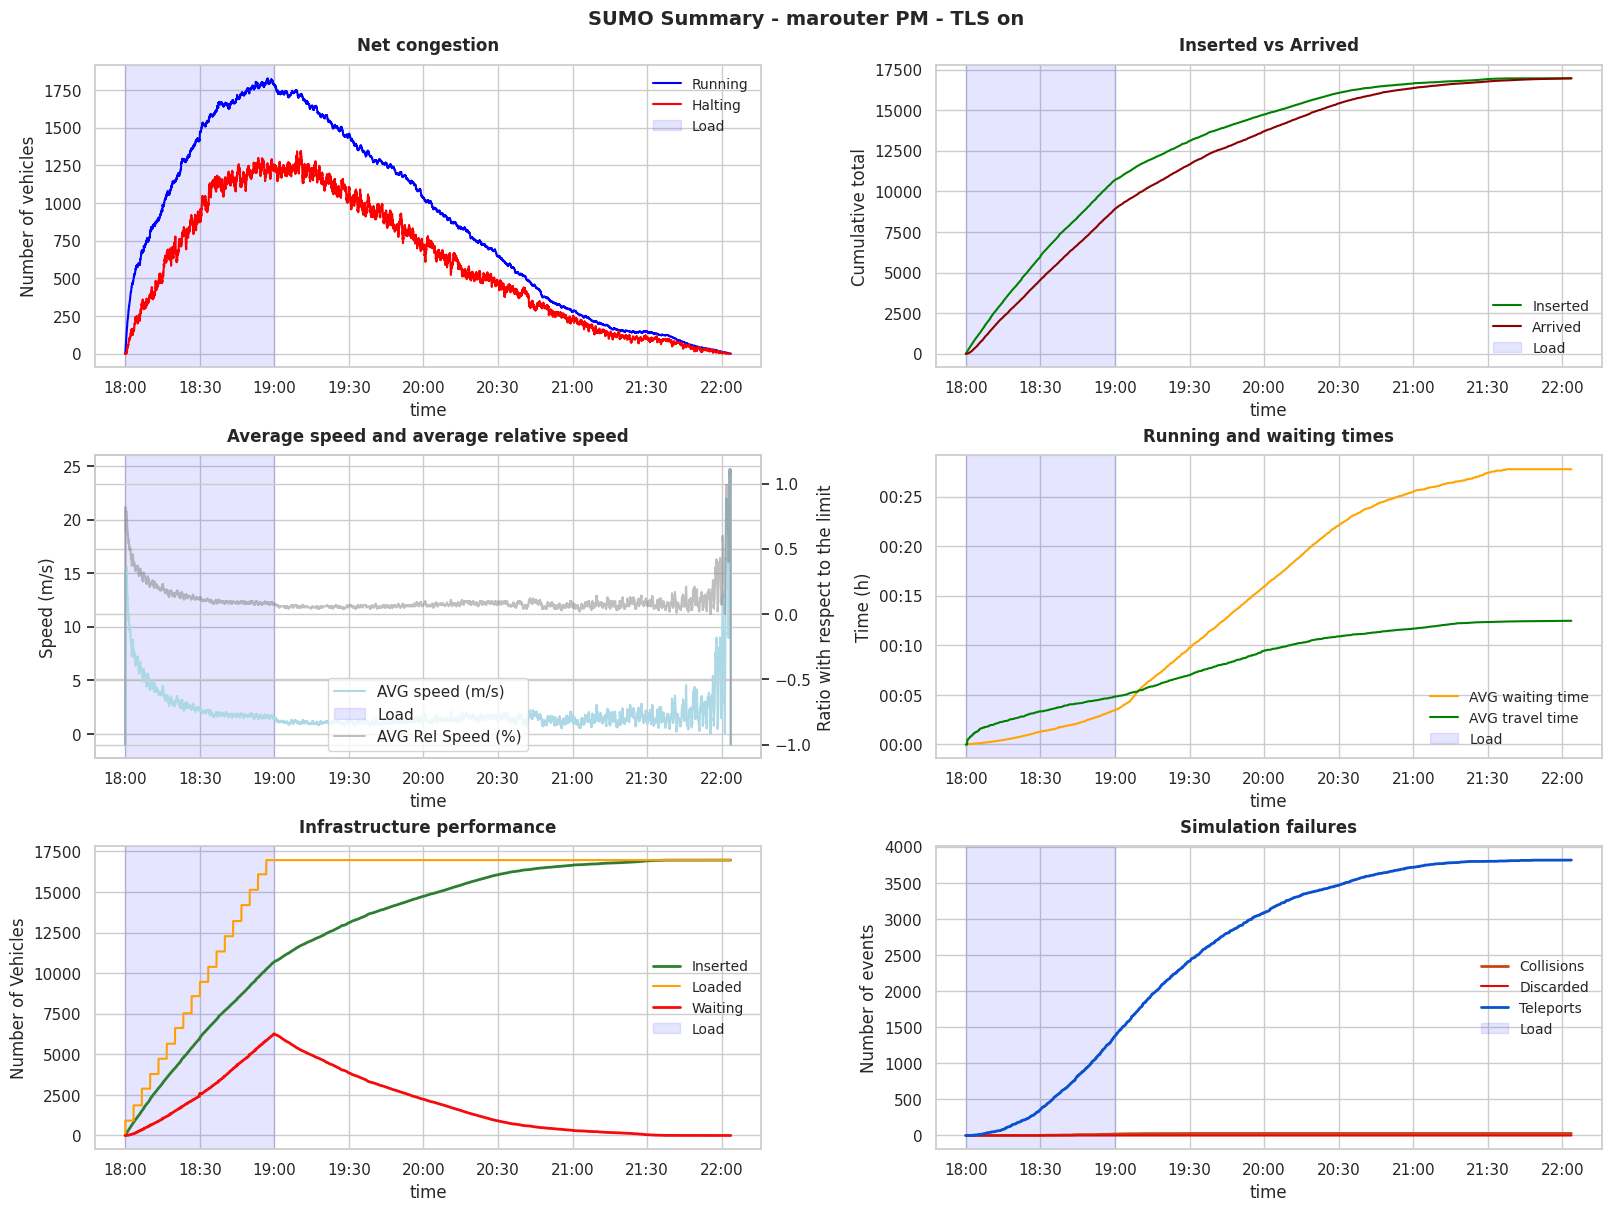

In [ ]:
plot_summary(
    df_ma_pm_tls,
    title="marouter PM - TLS on",
    xlim=20*3600,
    load_start=18*3600,
    load_end=19*3600,
)

## NIGHT PEAK

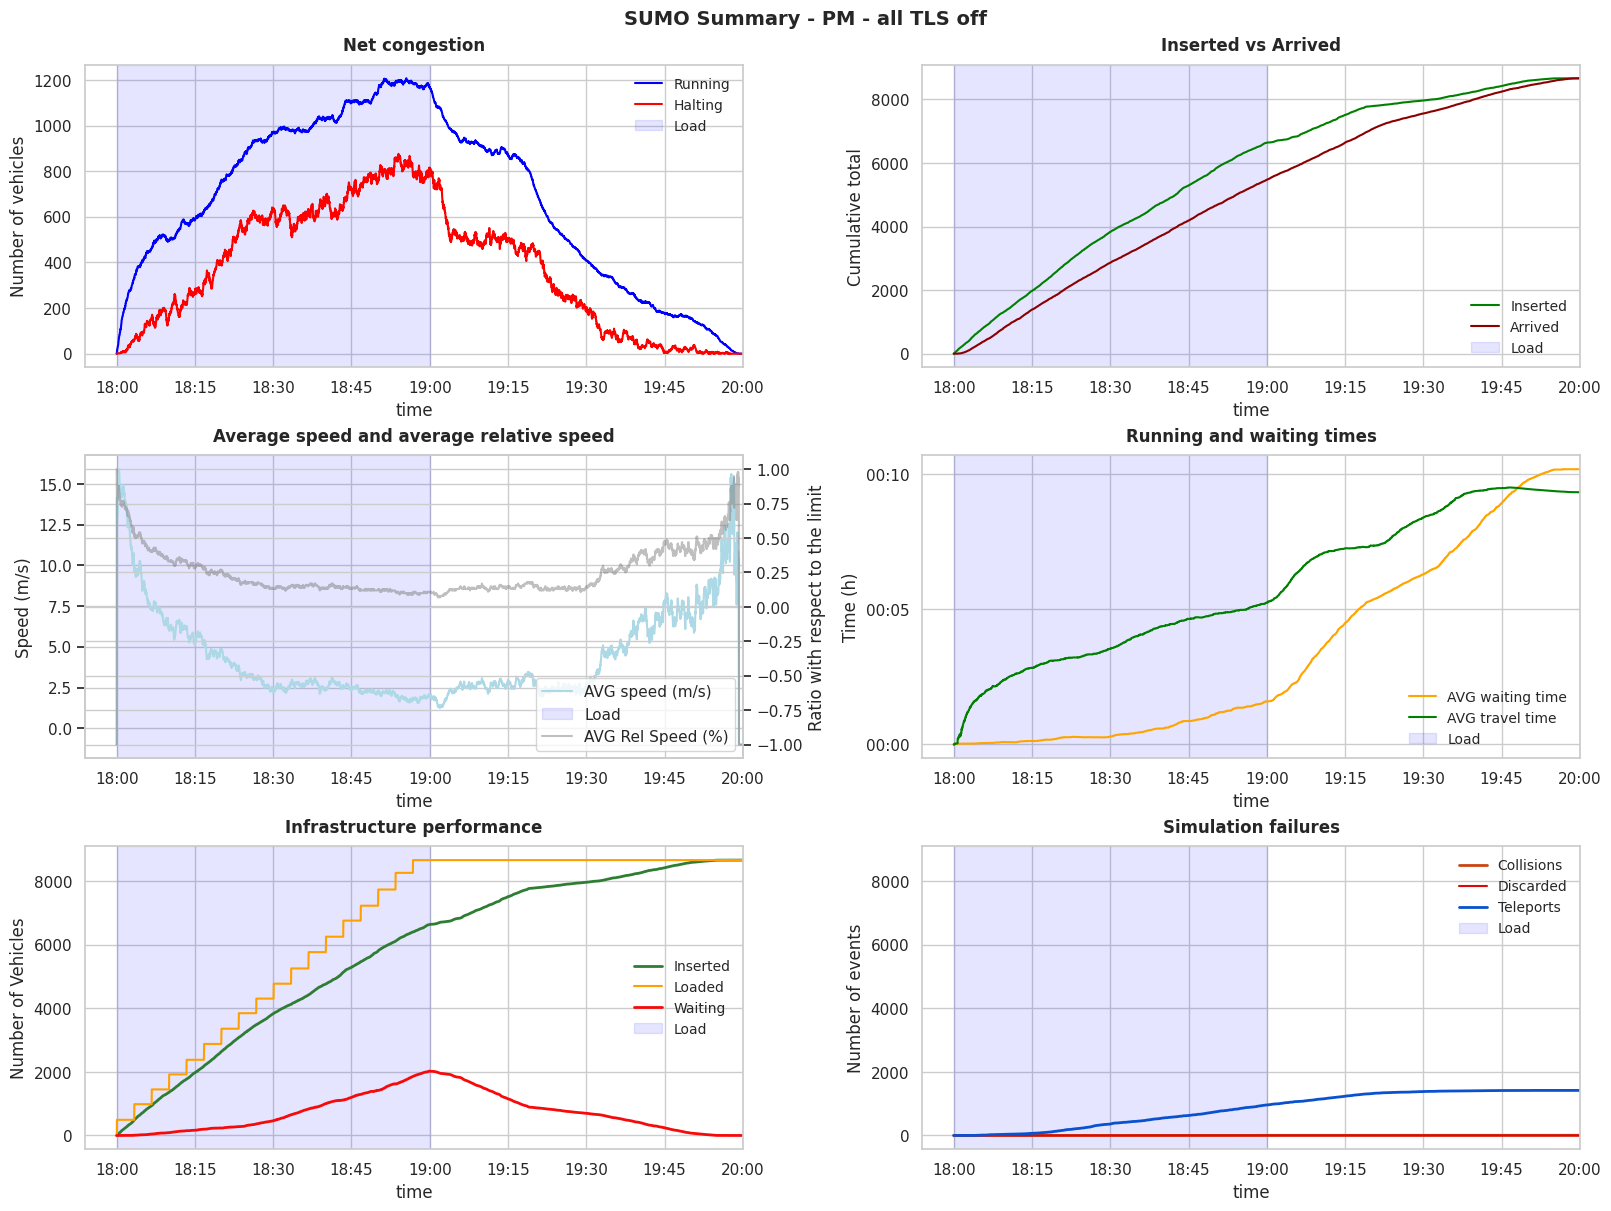

In [ ]:
# NO TLS
plot_summary(
    df_summary_pm_no_tls,
    title="PM - all TLS off",
    xlim=72000,
    load_start=18 * 3600,
    load_end=19 * 3600,
)

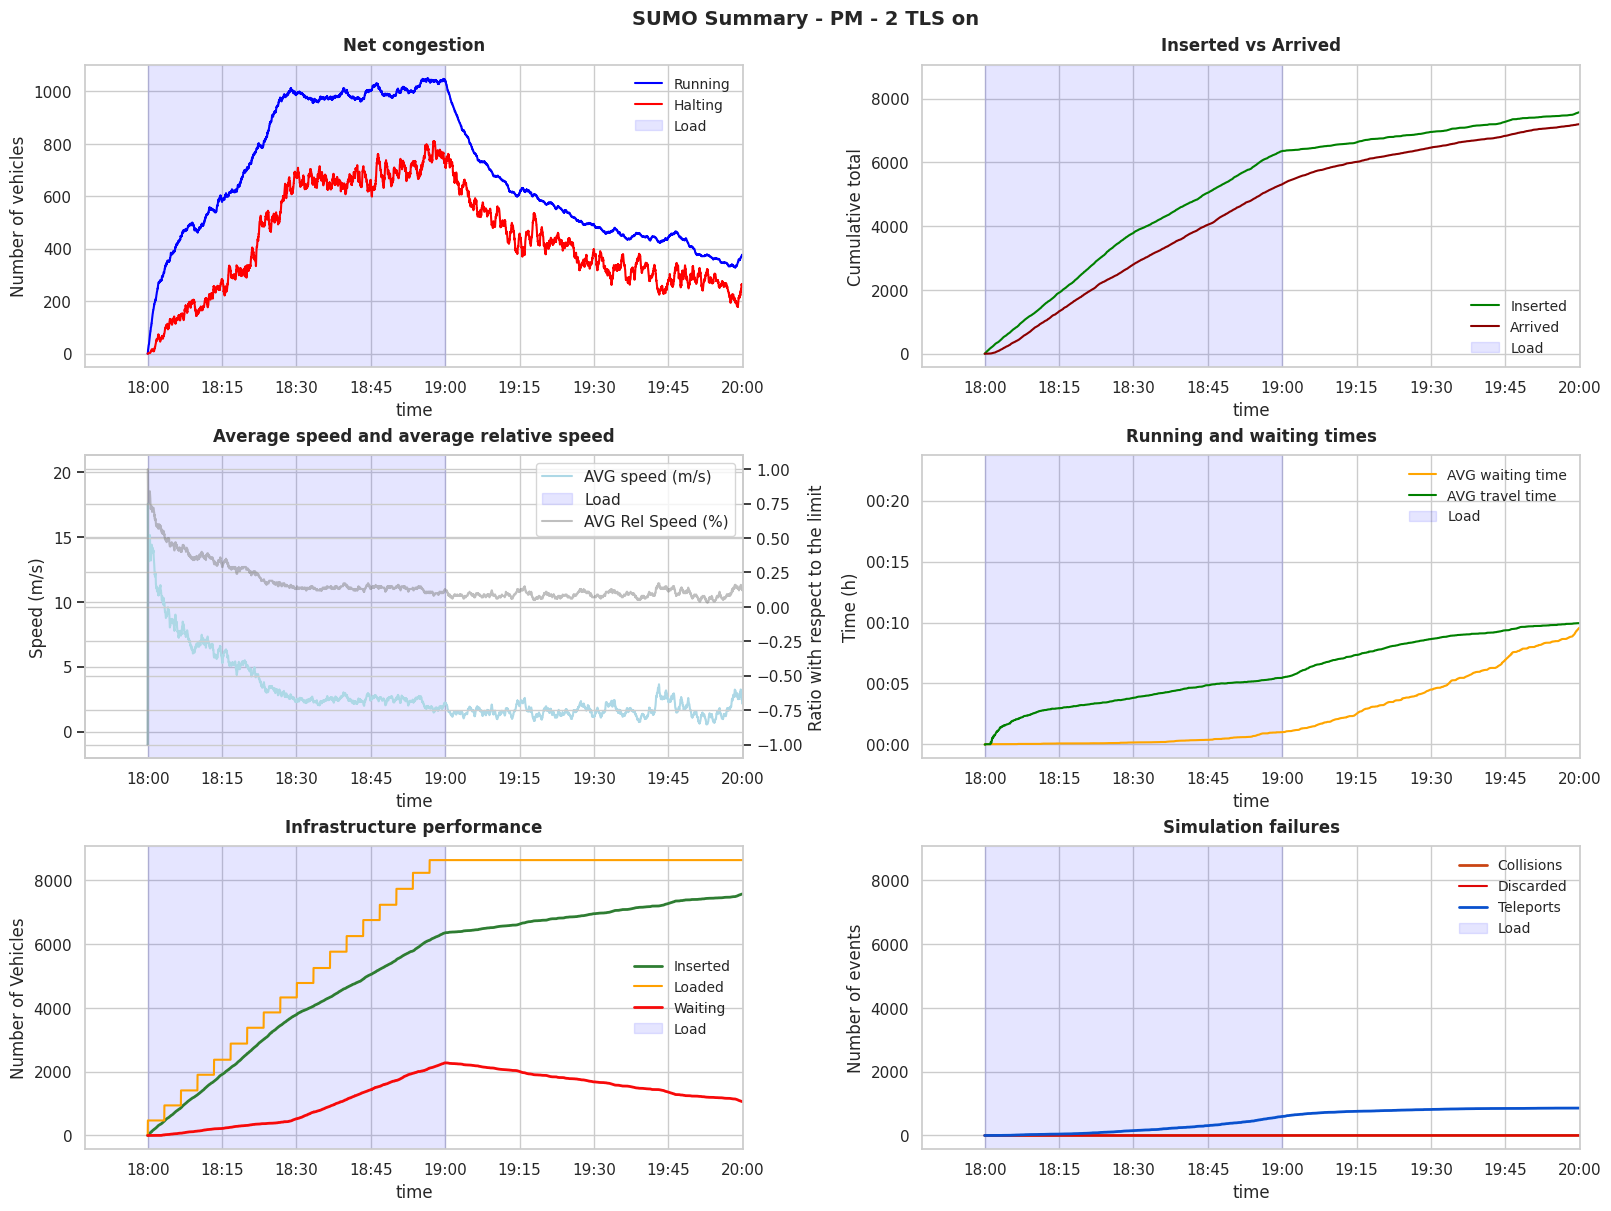

In [ ]:
# 2 TLS ON
plot_summary(
    df_summary_pm_tls,
    title="PM - 2 TLS on",
    xlim=72000,
    load_start=18 * 3600,
    load_end=19 * 3600,
)

In [ ]:
# plot_time_metrics(
#     df_tls=df_summary_pm_tls,
#     df_no_tls=df_summary_pm_no_tls,
#     xlim=20 * 3600,
#     title="Morning Peak",
#     load_start=18 * 3600,
#     load_end=19 * 3600,
# )

## night unloading

In [ ]:
path_unloaded_pm = r"/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/unloading/Summary_PM_dijkstra.xml"
df_pm_unload = parse_sumo_summary(path_unloaded_pm)
df_pm_unload = datetime_format(df_pm_unload)

/tmp/ipykernel_1305/24205668.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = pd.DataFrame(data).apply(pd.to_numeric, errors='ignore')


In [ ]:
df_pm_unload 

,time,loaded,inserted,running,waiting,ended,arrived,collisions,teleports,halting,stopped,meanWaitingTime,meanTravelTime,meanSpeed,meanSpeedRelative,discarded,duration,meanWaitingTime_dt,meanTravelTime_dt
0,1970-01-01 18:00:00,1,0,0,0,0,0,0,0,0,0,-1.00,-1.00,-1.00,-1.00,0,0,1969-12-31 23:59:59.000,1969-12-31 23:59:59.000
1,1970-01-01 18:00:01,1,0,0,0,0,0,0,0,0,0,-1.00,-1.00,-1.00,-1.00,0,0,1969-12-31 23:59:59.000,1969-12-31 23:59:59.000
2,1970-01-01 18:00:02,481,3,3,0,0,0,0,0,0,0,1.00,-1.00,13.93,1.00,0,110,1970-01-01 00:00:01.000,1969-12-31 23:59:59.000
3,1970-01-01 18:00:03,481,4,4,0,0,0,0,0,0,0,1.00,-1.00,15.94,0.99,0,0,1970-01-01 00:00:01.000,1969-12-31 23:59:59.000
4,1970-01-01 18:00:04,481,9,9,0,0,0,0,0,0,0,1.00,-1.00,14.16,0.95,0,1,1970-01-01 00:00:01.000,1969-12-31 23:59:59.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14959,1970-01-01 22:09:19,8651,8651,1,0,8650,8650,1,1391,0,0,1445.98,723.01,8.61,0.78,0,1,1970-01-01 00:24:05.980,1970-01-01 00:12:03.010
14960,1970-01-01 22:09:20,8651,8651,1,0,8650,8650,1,1391,0,0,1445.98,723.01,10.78,0.97,0,0,1970-01-01 00:24:05.980,1970-01-01 00:12:03.010
14961,1970-01-01 22:09:21,8651,8651,1,0,8650,8650,1,1391,0,0,1445.98,723.01,6.63,0.60,0,0,1970-01-01 00:24:05.980,1970-01-01 00:12:03.010
14962,1970-01-01 22:09:22,8651,8651,1,0,8650,8650,1,1391,0,0,1445.98,723.01,9.20,0.83,0,0,1970-01-01 00:24:05.980,1970-01-01 00:12:03.010


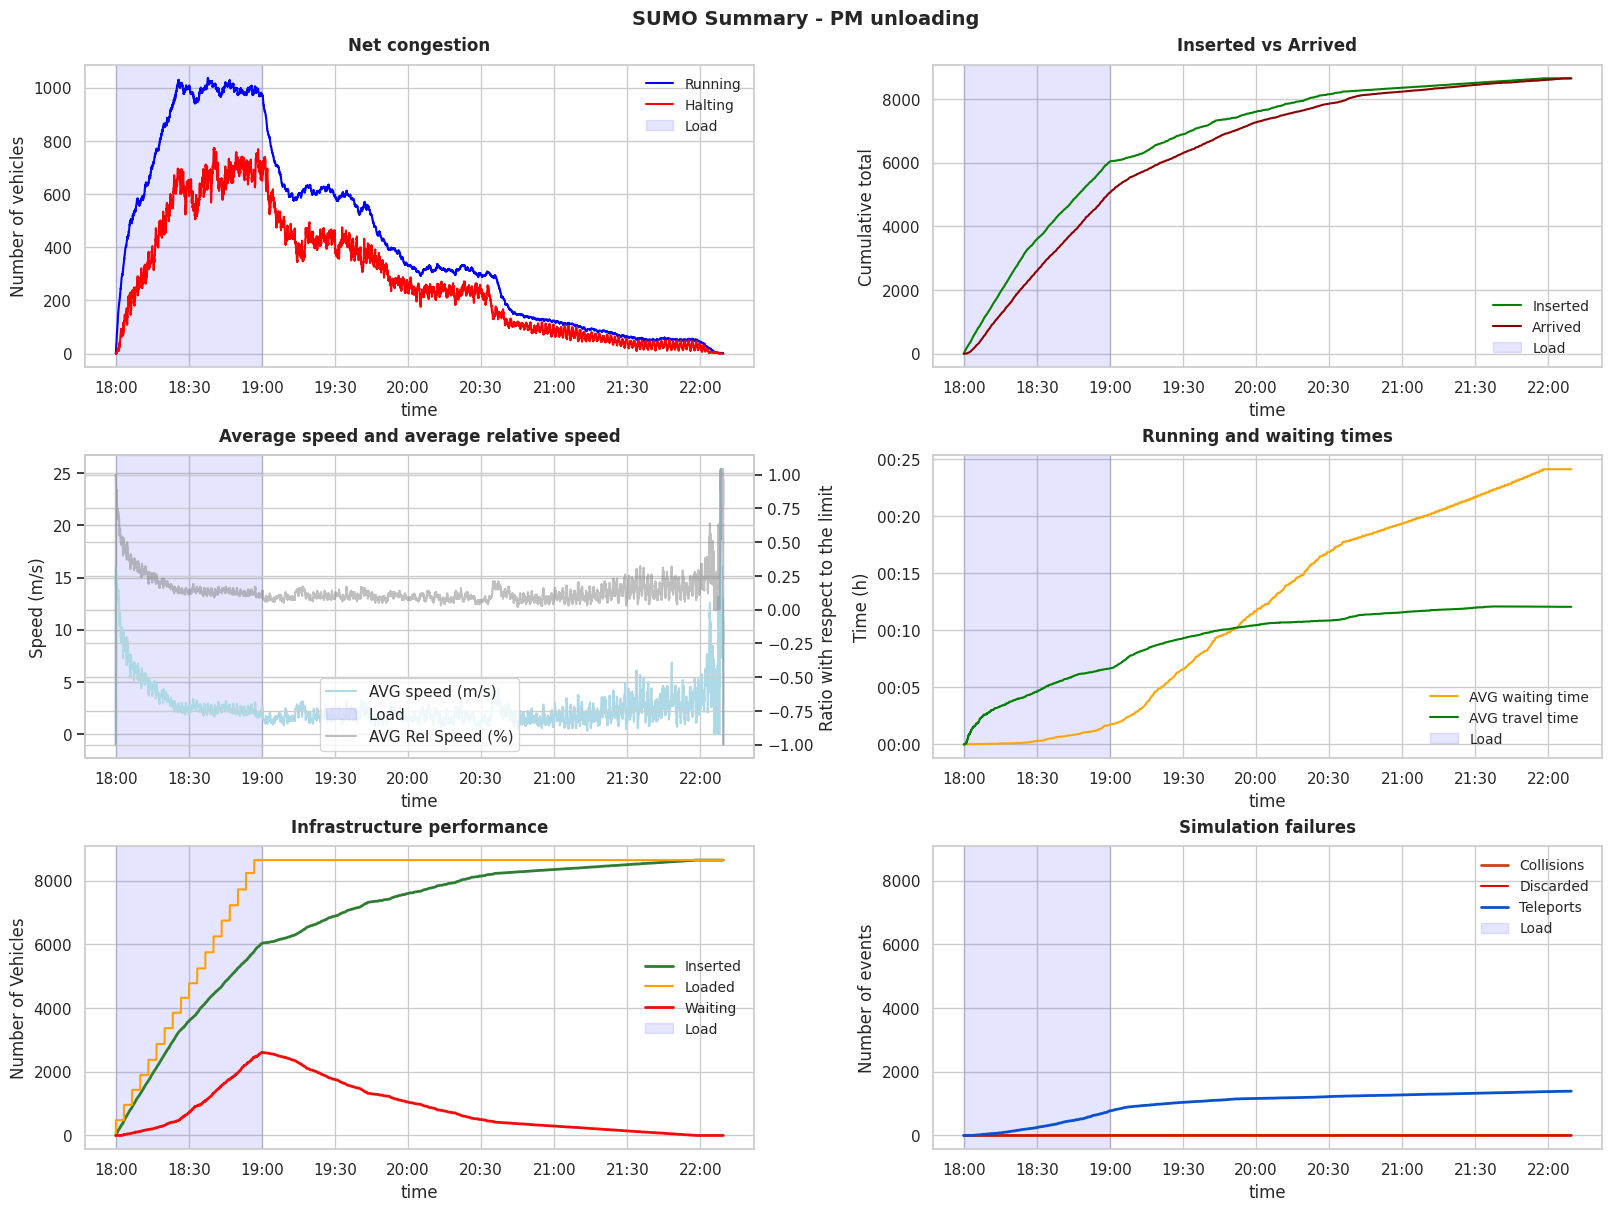

In [ ]:
# NO TLS
plot_summary(
    df_pm_unload,
    title="PM unloading",
    load_start=18 * 3600,
    load_end=19 * 3600,
)

## ALL-DAY SIMULATION

# DUAITERATE VS DUAROUTER (UE AND SUE)


In SUMO (Simulation of Urban MObility), the Logit model is primarily used within the Dynamic User Assignment (DUA) framework to model route choice behavior. It determines the probability of a driver choosing a specific route based on travel costs (usually time). 

The key LOGIT parameters in SUMO are typically configured within the router (e.g., duarouter) and control how travelers perceive and select routes.
Key Logit Parameters in SUMO
--route-choice-method logit: This activates the logit model for route choice instead of the default deterministic shortest path (All-or-Nothing).
Logit Scale Parameter (
 or "beta"): This is the most crucial parameter, often defined in combination with duarouter. It defines the sensitivity of travelers to route costs (travel time).
High Value (e.g., 


): Approaches Deterministic User Equilibrium (DUE), where travelers almost always pick the fastest route.
Low Value (e.g., 

): Routes are chosen almost uniformly at random, regardless of travel time.
--logit-beta: A parameter often used to define the sensitivity in the logit formula (

). It is related to the scale parameter 
.
--keep-all-routes: Often used alongside logit to allow the simulation to consider a broader set of alternatives. 

Context in Traffic Simulation
Stochastic User Equilibrium (SUE): Logit parameters are used to find a SUE, where no driver can unilaterally reduce their travel time, considering their varied perception of costs.
Route Choice Variance: While duarouter often produces deterministic routes, using logit allows for stochasticity, which is crucial for modelling realistic traffic distribution across multiple routes, particularly in congested networks.
Calibration: These parameters can be calibrated to fit real-world data, where low sensitivity (low 
) results in more spread-out traffic, and high sensitivity (high 
) concentrates traffic on the fastest route. 

These parameters are generally passed as arguments to duarouter when creating routes to be used by the sumo or sumo-gui simulation engines.

## MAROUTER

In [ ]:
path_marouter_am = r"/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/Summary_MAROUTER_AM_UNLOAD.xml"
df_summary_marouter_am = parse_sumo_summary(path_marouter_am)
df_summary_marouter_am = datetime_format(df_summary_marouter_am)

/tmp/ipykernel_3165/24205668.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = pd.DataFrame(data).apply(pd.to_numeric, errors='ignore')


In [ ]:
df_summary_marouter_am

,time,loaded,inserted,running,waiting,ended,arrived,collisions,teleports,halting,stopped,meanWaitingTime,meanTravelTime,meanSpeed,meanSpeedRelative,discarded,duration,meanWaitingTime_dt,meanTravelTime_dt
0,1970-01-01 08:00:00,557,126,126,431,0,0,0,0,17,0,0.00,-1.00,13.58,0.81,0,159,1970-01-01 00:00:00.000,1969-12-31 23:59:59.000
1,1970-01-01 08:00:01,557,202,178,355,24,24,0,0,5,0,0.38,1.00,13.06,0.77,0,34,1970-01-01 00:00:00.380,1970-01-01 00:00:01.000
2,1970-01-01 08:00:02,557,246,204,311,42,42,0,0,4,0,0.67,1.05,11.91,0.70,0,20,1970-01-01 00:00:00.670,1970-01-01 00:00:01.050
3,1970-01-01 08:00:03,557,276,228,281,48,48,0,0,18,0,0.92,1.17,10.81,0.63,0,19,1970-01-01 00:00:00.920,1970-01-01 00:00:01.170
4,1970-01-01 08:00:04,557,302,245,255,57,57,0,0,8,0,1.19,1.33,10.41,0.61,0,13,1970-01-01 00:00:01.190,1970-01-01 00:00:01.330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16802,1970-01-01 12:40:02,26525,26525,1,0,26524,26524,13,3798,0,0,2757.52,483.88,11.96,0.86,0,0,1970-01-01 00:45:57.520,1970-01-01 00:08:03.880
16803,1970-01-01 12:40:03,26525,26525,1,0,26524,26524,13,3798,0,0,2757.52,483.88,11.43,0.82,0,0,1970-01-01 00:45:57.520,1970-01-01 00:08:03.880
16804,1970-01-01 12:40:04,26525,26525,1,0,26524,26524,13,3798,0,0,2757.52,483.88,12.19,0.88,0,0,1970-01-01 00:45:57.520,1970-01-01 00:08:03.880
16805,1970-01-01 12:40:05,26525,26525,1,0,26524,26524,13,3798,0,0,2757.52,483.88,11.50,0.83,0,0,1970-01-01 00:45:57.520,1970-01-01 00:08:03.880


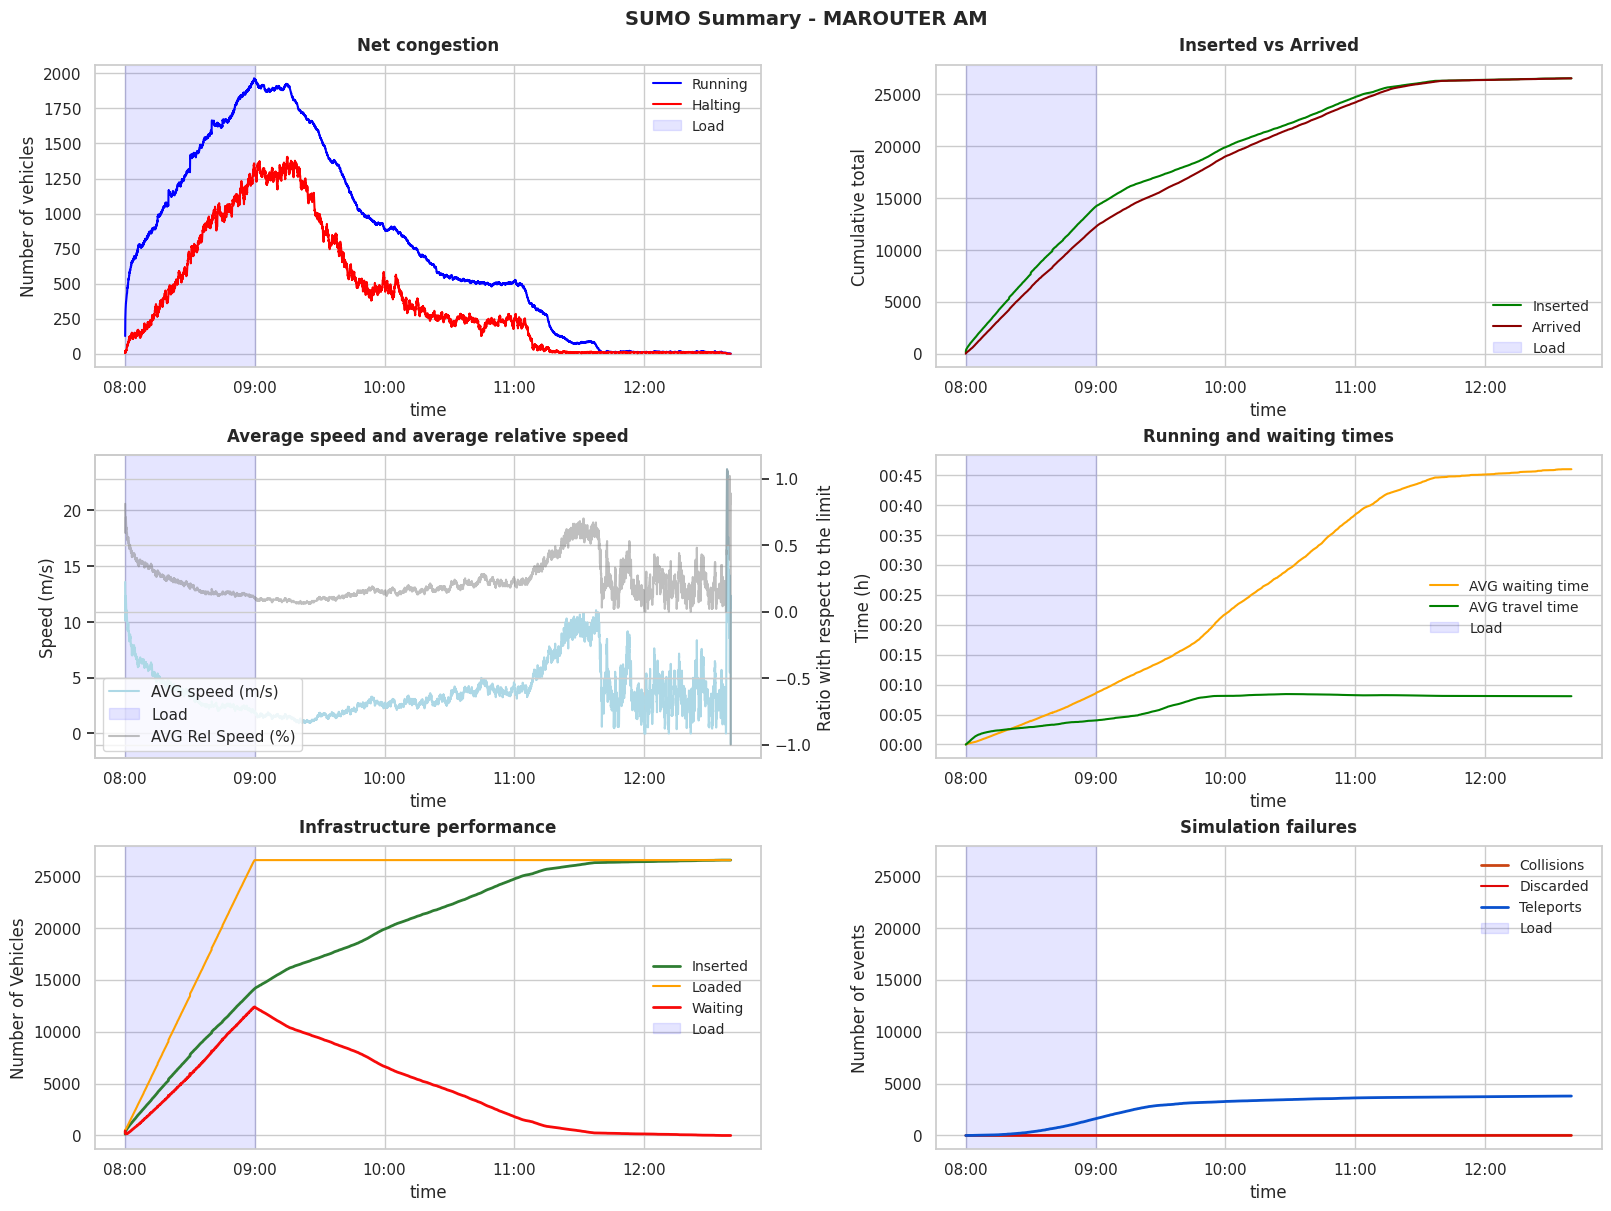

In [ ]:
plot_summary(
    df_summary_marouter_am,
    title="MAROUTER AM",
    load_start= 8* 3600,
    load_end=9 * 3600
)

In [ ]:
path_marouter_pm = r"/home/fullsuper/irene/dtSumo/scripts/output/simulation-out/Summary_MAROUTER_PM_UNLOAD.xml"
df_summary_marouter_pm = parse_sumo_summary(path_marouter_pm)
df_summary_marouter_pm = datetime_format(df_summary_marouter_pm)

/tmp/ipykernel_3165/24205668.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = pd.DataFrame(data).apply(pd.to_numeric, errors='ignore')


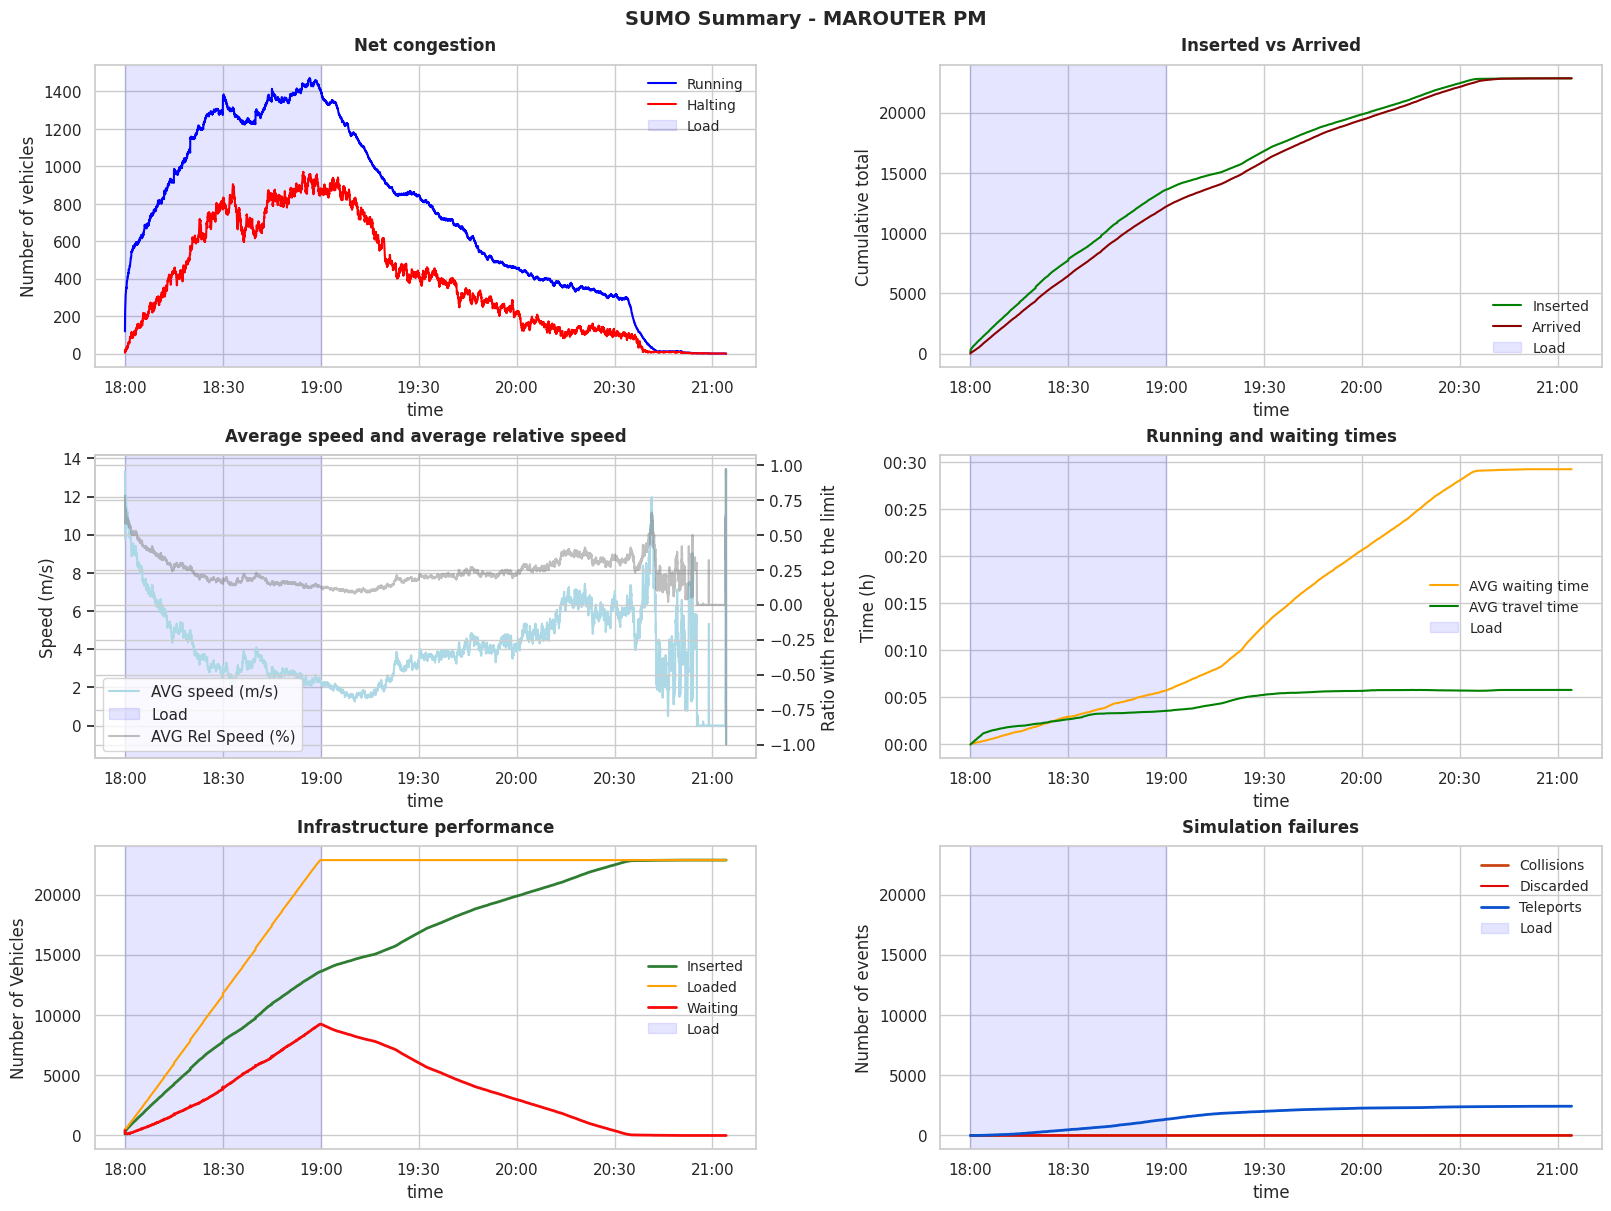

In [ ]:
plot_summary(
    df_summary_marouter_pm,
    title="MAROUTER PM",
    load_start= 18* 3600,
    load_end=19 * 3600
)

In [ ]:
df_summary_marouter_pm

,time,loaded,inserted,running,waiting,ended,arrived,collisions,teleports,halting,stopped,meanWaitingTime,meanTravelTime,meanSpeed,meanSpeedRelative,discarded,duration,meanWaitingTime_dt,meanTravelTime_dt
0,1970-01-01 18:00:00,536,119,119,417,0,0,0,0,16,0,0.00,-1.00,13.31,0.78,0,40,1970-01-01 00:00:00.000,1969-12-31 23:59:59.000
1,1970-01-01 18:00:01,536,190,168,346,22,22,0,0,5,0,0.37,1.00,12.88,0.75,0,18,1970-01-01 00:00:00.370,1970-01-01 00:00:01.000
2,1970-01-01 18:00:02,536,237,197,299,40,40,0,0,7,0,0.70,1.02,11.23,0.66,0,7,1970-01-01 00:00:00.700,1970-01-01 00:00:01.020
3,1970-01-01 18:00:03,536,264,219,272,45,45,0,0,19,0,0.93,1.18,10.23,0.60,0,10,1970-01-01 00:00:00.930,1970-01-01 00:00:01.180
4,1970-01-01 18:00:04,536,285,233,251,52,52,0,0,9,0,1.16,1.38,10.12,0.60,0,5,1970-01-01 00:00:01.160,1970-01-01 00:00:01.380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11048,1970-01-01 21:04:08,22859,22859,1,0,22858,22858,8,2429,0,0,1754.04,347.38,13.12,0.94,0,0,1970-01-01 00:29:14.040,1970-01-01 00:05:47.380
11049,1970-01-01 21:04:09,22859,22859,1,0,22858,22858,8,2429,0,0,1754.04,347.38,12.76,0.92,0,0,1970-01-01 00:29:14.040,1970-01-01 00:05:47.380
11050,1970-01-01 21:04:10,22859,22859,1,0,22858,22858,8,2429,0,0,1754.04,347.38,13.43,0.97,0,0,1970-01-01 00:29:14.040,1970-01-01 00:05:47.380
11051,1970-01-01 21:04:11,22859,22859,1,0,22858,22858,8,2429,0,0,1754.04,347.38,13.09,0.94,0,0,1970-01-01 00:29:14.040,1970-01-01 00:05:47.380


In [ ]:
dfs = {
    "am_no_tls": df_am_unload,
    "am_tls": df_summary_am_tls,
    "pm_no_tls": df_pm_unload,
    "pm_tls": df_summary_pm_tls,
    "am_marouter_no_tls": df_summary_marouter_am,
    "pm_marouter_no_tls": df_summary_marouter_pm,
    "am_iterate": df_summary_dua_am,
    "pm_iterate": df_summary_dua_pm_29,
    "am_logit_001": df_summary_logit_am_001,
    "am_logit_015": df_summary_logit_am_015,
    "am_logit_05": df_summary_logit_pm_05,
    "pm_logit_001": df_summary_logit_pm_001,
    "pm_logit_015": df_summary_logit_pm_015,
    "pm_logit_05": df_summary_logit_pm_05,
    "am_gawron_a01_b05": df_summary_gawron_am_a01_b05,
    "am_gawron_a03_b09": df_summary_gawron_am_a03_b09,
    "am_gawron_a05_b09": df_summary_gawron_am_a05_b09,
    "pm_gawron_a01_b05": df_summary_gawron_pm_a01_b05,
    "pm_gawron_a03_b09": df_summary_gawron_pm_a03_b09,
    "pm_gawron_a05_b09": df_summary_gawron_pm_a05_b09,
}

In [ ]:
import datetime

ending_moments = {}

for name, df in dfs.items():
    start = df["time"].min()
    end_load = start + pd.Timedelta(hours=1)
    end_sim = df["time"].max()
    delta_unload = end_sim - end_load
    ending_moments[name] = {
        "delta_unload": str(datetime.timedelta(seconds=delta_unload.total_seconds())),
        "start": start.strftime("%H:%M:%S"),
        "end_load": end_load.strftime("%H:%M:%S"),
        "end": end_sim.strftime("%H:%M:%S"),
    }


ending_table = pd.DataFrame.from_dict(ending_moments, orient="index")
ending_table

,delta_unload,start,end_load,end
am_no_tls,3:48:39,08:00:00,09:00:00,12:48:39
am_tls,3:35:06,08:00:00,09:00:00,12:35:06
pm_no_tls,3:09:23,18:00:00,19:00:00,22:09:23
pm_tls,3:00:14,18:00:00,19:00:00,22:00:14
am_marouter_no_tls,3:40:06,08:00:00,09:00:00,12:40:06
pm_marouter_no_tls,2:04:12,18:00:00,19:00:00,21:04:12
am_iterate,0:59:59,08:00:00,09:00:00,09:59:59
pm_iterate,0:59:59,18:00:00,19:00:00,19:59:59
am_logit_001,0:59:59,08:00:00,09:00:00,09:59:59
am_logit_015,0:59:59,08:00:00,09:00:00,09:59:59
